# Liu2024 Source MAT SignalJEPA PreLocal

Configurable preprocessing sweep notebook for testing S-JEPA PreLocal (`new` + pretrained) on Liu2024 source `.mat` trials.

# 1. Setup

In [1]:
import os

import re
import sys
import json
import math
import hashlib
import random
import builtins
import platform
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, Subset

from scipy.io import loadmat
from scipy import signal

from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix

from skorch.callbacks import EarlyStopping, EpochScoring
from skorch.dataset import ValidSplit

from braindecode import EEGClassifier
from braindecode.models import SignalJEPA_PreLocal

import mne

mne.set_log_level("WARNING")
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"


/home/vegorov/Repos/eeg_jepa_research/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print("Runtime Environment:")
print(f"  - Python: {sys.version}")
print(f"  - Platform: {platform.platform()}")

WORKING_DIR = Path.cwd().resolve().parent.parent
print(f"\nWorking directory: {WORKING_DIR}")


Runtime Environment:
  - Python: 3.11.15 (main, Mar 24 2026, 22:50:29) [Clang 22.1.1 ]
  - Platform: Linux-6.14.0-37-generic-x86_64-with-glibc2.41

Working directory: /home/vegorov/Repos/eeg_jepa_research


# 2. Configuration

## 2.1 Liu2024 Channel Defaults

In [3]:
# Liu2024 source MAT channel conventions.
# Source files are organized as trials x 33 channels x samples:
#   0..29 = EEG-like channels, index 17 = CPz source reference,
#   30..31 = EOG, 32 = marker.
#
# The channel labels below follow the Liu2024 paper / EEGLAB location files.
# This matters for montage-dependent topomaps and any channel-position metadata.
SOURCE_EEG_CHANNEL_INDICES_30 = list(range(30))
SOURCE_REFERENCE_INDEX = 17
SOURCE_EEG_CHANNEL_INDICES_29 = [i for i in SOURCE_EEG_CHANNEL_INDICES_30 if i != SOURCE_REFERENCE_INDEX]

SOURCE_EEG_CHANNEL_NAMES_30 = [
    "Fp1", "Fp2", "Fz", "F3", "F4", "F7", "F8", "FCz", "FC3", "FC4",
    "FT7", "FT8", "Cz", "C3", "C4", "T3", "T4", "CPz",
    "CP3", "CP4", "TP7", "TP8", "Pz", "P3", "P4", "T5", "T6", "Oz", "O1", "O2",
]

# EOG and marker channels available in Liu2024 source MAT files.
SOURCE_EOG_CHANNEL_INDICES = [30, 31]
SOURCE_MARKER_CHANNEL_INDEX = 32


## 2.2 CONFIG

In [4]:
WORKING_DIR = Path.cwd().resolve().parent.parent

CONFIG = {
    # ------------------------------------------------------------------
    # Paths / run identity
    # ------------------------------------------------------------------
    "artifact_dir": str(WORKING_DIR / "artifacts" / "liu2024-source-mat-sjepa-prelocal"),
    "source_extract_dir": str(WORKING_DIR / "liu2024_data" / "liu2024_figshare" / "sourcedata"),
    "experiment_name": "baseline_sjepa_prelocal",
    "config_note": "Clean MNE-style preprocessing pipeline builder + S-JEPA hyperparameter controls.",

    # ------------------------------------------------------------------
    # Dataset
    # ------------------------------------------------------------------
    "subjects_to_use": None,
    "exclude_subjects": [],
    "source_unit": "microvolts",
    "final_model_unit": "microvolts",

    # ------------------------------------------------------------------
    # Source-domain preprocessing before creating MNE RawArray
    # ------------------------------------------------------------------
    "demean_mode": "baseline_window_mean",      # none, trial_mean, baseline_window_mean
    "baseline_window_s": [0.0, 2.0],
    "detrend_mode": "none",                     # none, constant, linear
    "eog_correction": "none",                   # none, linear_regression

    # Robust source-domain clipping / winsorization. Use cautiously.
    "artifact_clip_mode": "none",               # none, absolute, percentile
    "artifact_clip_abs_value": None,             # in source_unit, e.g. 150.0 when source_unit=microvolts
    "artifact_clip_percentile": 99.5,

    # ------------------------------------------------------------------
    # MNE Raw-level preprocessing
    # ------------------------------------------------------------------
    "reference_mode": "average",                # average, none
    "reference_timing": "before_resample_filter",  # before_resample_filter, after_resample_before_filter, after_filter
    "resample": True,
    "resample_sfreq": 128,

    "filter_enabled": True,
    "filter_low": 0.5,
    "filter_high": 40.0,
    "filter_method": "fir",                     # fir, iir
    "filter_phase": "zero",                     # zero, zero-double, minimum (FIR only)
    "filter_fir_design": "firwin",              # firwin, firwin2 (FIR only)
    "filter_l_trans_bandwidth": "auto",         # auto or float, FIR only
    "filter_h_trans_bandwidth": "auto",         # auto or float, FIR only
    "filter_iir_params": None,                    # example: {"order": 2, "ftype": "butter"}

    "notch_freqs": None,                          # example: [50.0]
    "notch_before_bandpass": False,

    # ------------------------------------------------------------------
    # Windowing and post-window cleaning
    # ------------------------------------------------------------------
    "target_window_s": 4.2,
    "target_window_samples": 537,
    "mi_window_start_s": 2,

    "reject_bad_trials": False,
    "reject_peak_to_peak_threshold": None,       # in final_model_unit
    "reject_abs_threshold": None,                # in final_model_unit
    "min_trials_per_class_after_reject": None,

    # ------------------------------------------------------------------
    # Fold-safe normalization. train_* modes are fit on each training split only.
    # ------------------------------------------------------------------
    "normalization_mode": "none",               # none, train_global_zscore, train_channel_zscore, train_channel_robust, trial_global_zscore, trial_channel_zscore
    "normalization_eps": 1e-6,

    # ------------------------------------------------------------------
    # Model / downstream strategy
    # ------------------------------------------------------------------
    "model_name": "SignalJEPA_PreLocal",
    "pretrained_mode": "from_pretrained",
    "pretrained_repo_id": "braindecode/signal-jepa_without-chans",
    "strategy": "new",                          # new, full
    "warmup_epochs": 10,

    # ------------------------------------------------------------------
    # Evaluation protocol
    # ------------------------------------------------------------------
    "evaluation_mode": "stratified_kfold",      # stratified_kfold, liu2024_repeated_60_40, repeated_stratified_split
    "cv_folds": 5,
    "n_repeats": 10,
    "test_size": 0.4,
    "split_random_state": 2026,
    "assert_balanced_folds": True,

    # ------------------------------------------------------------------
    # Training hyperparameters
    # ------------------------------------------------------------------
    "batch_size": 8,
    "n_epochs": 5000,
    "early_stopping_patience": 50,
    "val_split": 0.2,
    "learning_rate": 0.0004,
    "optimizer_name": "adam",                   # adam, adamw
    "weight_decay": 0.0,
    "gradient_clip_norm": None,
    "checkpoint_metric": "valid_loss",           # valid_loss, valid_balanced_accuracy
    "label_smoothing": 0.0,
    "prediction_balance_loss_weight": 0.0,

    # Lightweight training-time augmentation.
    "augmentation_noise_fraction": 0.0,
    "augmentation_time_shift_samples": 0,
    "augmentation_channel_dropout_prob": 0.0,

    # ------------------------------------------------------------------
    # Reproducibility
    # ------------------------------------------------------------------
    "seed": 2026,
    "set_seed": True,
    "cv_random_state": 2026,
    "val_split_random_state": 2026,

    # ------------------------------------------------------------------
    # Diagnostics / interpretation
    # ------------------------------------------------------------------
    "extract_spatial_conv_weights": True,
    "save_spatial_weight_plots": False,
    "plot_individual_spatial_filters": False,
    "max_spatial_filters_to_plot": 8,
    "topomap_dpi": 160,
    "topomap_value_mode": "relative_zscore",    # raw, relative_zscore, relative_percent
    "topomap_cmap": "RdBu_r",
    "collapse_threshold": 0.9,
    "log_spatial_update_stats": True,
    "log_probability_diagnostics": True,
}

In [5]:
# Liu2024 source MAT constants.
LIU_SOURCE_SFREQ = 500
LIU_EXPECTED_TRIALS_PER_SUBJECT = 40
LIU_EXPECTED_SOURCE_CHANNELS = 33
LIU_EXPECTED_SOURCE_SAMPLES_PER_TRIAL = 4000

# Liu source MAT files include EEG + EOG + marker channels.
# Keep the 29 EEG channels used in the Liu paper baseline and drop CPz because it is the source reference channel.
EEG_CHANNEL_INDICES = SOURCE_EEG_CHANNEL_INDICES_29
EEG_CHANNEL_NAMES = [
    name for idx, name in enumerate(SOURCE_EEG_CHANNEL_NAMES_30)
    if idx != SOURCE_REFERENCE_INDEX
]

SOURCE_EXTRACT_DIR = Path(CONFIG["source_extract_dir"])
TARGET_N_CLASSES = 2

if bool(CONFIG.get("resample", True)):
    EFFECTIVE_SFREQ = float(CONFIG.get("resample_sfreq", 128))
else:
    EFFECTIVE_SFREQ = float(LIU_SOURCE_SFREQ)

CONFIG["effective_sfreq"] = EFFECTIVE_SFREQ
CONFIG["sfreq"] = EFFECTIVE_SFREQ  # compatibility with existing cells/artifacts

if CONFIG.get("target_window_samples", None) is None:
    WINDOW_SAMPLES = int(round(float(CONFIG["target_window_s"]) * EFFECTIVE_SFREQ))
else:
    WINDOW_SAMPLES = int(CONFIG["target_window_samples"])

TARGET_TRIAL_DURATION_S = WINDOW_SAMPLES / EFFECTIVE_SFREQ
MI_WINDOW_START_SAMPLE = int(round(float(CONFIG["mi_window_start_s"]) * EFFECTIVE_SFREQ))
MI_WINDOW_STOP_SAMPLE = MI_WINDOW_START_SAMPLE + WINDOW_SAMPLES

PREPROCESSING_KEYS = [
    "source_unit", "final_model_unit",
    "demean_mode", "baseline_window_s", "detrend_mode", "eog_correction",
    "artifact_clip_mode", "artifact_clip_abs_value", "artifact_clip_percentile",
    "reference_mode", "reference_timing", "resample", "resample_sfreq", "effective_sfreq",
    "filter_enabled", "filter_low", "filter_high", "filter_method", "filter_phase",
    "filter_fir_design", "filter_l_trans_bandwidth", "filter_h_trans_bandwidth", "filter_iir_params",
    "notch_freqs", "notch_before_bandpass",
    "mi_window_start_s", "target_window_s", "target_window_samples",
    "reject_bad_trials", "reject_peak_to_peak_threshold", "reject_abs_threshold",
    "normalization_mode", "normalization_eps",
]

TRAINING_KEYS = [
    "strategy", "batch_size", "learning_rate", "optimizer_name", "weight_decay",
    "val_split", "early_stopping_patience", "n_epochs",
    "augmentation_noise_fraction", "augmentation_time_shift_samples", "augmentation_channel_dropout_prob",
]

EVALUATION_KEYS = [
    "evaluation_mode", "cv_folds", "n_repeats", "test_size",
    "cv_random_state", "split_random_state", "val_split_random_state",
]

def summarize_selected_config(keys):
    return {k: CONFIG.get(k) for k in keys}

PREPROCESSING_CONFIG = summarize_selected_config(PREPROCESSING_KEYS)
TRAINING_CONFIG = summarize_selected_config(TRAINING_KEYS)
EVALUATION_CONFIG = summarize_selected_config(EVALUATION_KEYS)

def print_config_block(title, values):
    print(title)
    for key, value in values.items():
        print(f"  {key:34s}: {value}")

print("Effective Liu2024 Source MAT settings:")
print(f"  Experiment:                        {CONFIG.get('experiment_name')}")
print(f"  Note:                              {CONFIG.get('config_note')}")
print(f"  Channels:                          {len(EEG_CHANNEL_NAMES)}")
print(f"  Channel names:                     {EEG_CHANNEL_NAMES}")
print(f"  Source sfreq:                      {LIU_SOURCE_SFREQ} Hz")
print(f"  Effective sfreq:                   {EFFECTIVE_SFREQ} Hz")
print(f"  MI window start / samples:         {CONFIG['mi_window_start_s']} s / {WINDOW_SAMPLES}")
print(f"  Effective window duration:         {TARGET_TRIAL_DURATION_S:.4f} s")
print(f"  Evaluation mode:                   {CONFIG.get('evaluation_mode')}")
print(f"  Fixed seed:                        base={CONFIG.get('seed')} | cv={CONFIG.get('cv_random_state')} | split={CONFIG.get('split_random_state')} | val={CONFIG.get('val_split_random_state')}")
print_config_block("\nPreprocessing config:", PREPROCESSING_CONFIG)
print_config_block("\nTraining config:", TRAINING_CONFIG)
print_config_block("\nEvaluation config:", EVALUATION_CONFIG)


Effective Liu2024 Source MAT settings:
  Experiment:                        baseline_sjepa_prelocal
  Note:                              Clean MNE-style preprocessing pipeline builder + S-JEPA hyperparameter controls.
  Channels:                          29
  Channel names:                     ['Fp1', 'Fp2', 'Fz', 'F3', 'F4', 'F7', 'F8', 'FCz', 'FC3', 'FC4', 'FT7', 'FT8', 'Cz', 'C3', 'C4', 'T3', 'T4', 'CP3', 'CP4', 'TP7', 'TP8', 'Pz', 'P3', 'P4', 'T5', 'T6', 'Oz', 'O1', 'O2']
  Source sfreq:                      500 Hz
  Effective sfreq:                   128.0 Hz
  MI window start / samples:         2 s / 537
  Effective window duration:         4.1953 s
  Evaluation mode:                   stratified_kfold
  Fixed seed:                        base=2026 | cv=2026 | split=2026 | val=2026

Preprocessing config:
  source_unit                       : microvolts
  final_model_unit                  : microvolts
  demean_mode                       : baseline_window_mean
  baseline_window_s  

## 2.3 Artifact Creation and Logging Init

In [6]:
def create_run_id():
    timestamp = datetime.now().strftime("%Y%m%d_%H%M")
    config_str = json.dumps(CONFIG, sort_keys=True, default=str)
    config_hash = hashlib.md5(config_str.encode()).hexdigest()[:8]
    return f"{timestamp}_{config_hash}"

RUN_ID = create_run_id()
ARTIFACT_DIR = Path(CONFIG["artifact_dir"]) / RUN_ID
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

LOG_PATH = ARTIFACT_DIR / "run.log"
_LOG_FILE_HANDLE = open(LOG_PATH, "a", buffering=1, encoding="utf-8", errors="replace")

def _safe_write_text(stream, text):
    try:
        stream.write(text)
        return
    except UnicodeEncodeError:
        pass

    encoding = getattr(stream, "encoding", None) or "utf-8"
    safe_text = text.encode(encoding, errors="replace").decode(encoding, errors="replace")
    stream.write(safe_text)

def _timestamped_print(*args, **kwargs):
    sep = kwargs.pop("sep", " ")
    end = kwargs.pop("end", "\n")
    flush = kwargs.pop("flush", False)
    file = kwargs.pop("file", None)
    message = sep.join(str(arg) for arg in args)
    leading_newlines = len(message) - len(message.lstrip("\n"))
    message_body = message[leading_newlines:]

    def _write_target(text):
        if file is None:
            _safe_write_text(sys.stdout, text)
            if flush:
                sys.stdout.flush()
        else:
            _safe_write_text(file, text)
            if flush and hasattr(file, "flush"):
                file.flush()

    if leading_newlines > 0:
        blanks = "\n" * leading_newlines
        _write_target(blanks)
        _safe_write_text(_LOG_FILE_HANDLE, blanks)

    if message_body:
        ts = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        stamped = f"[{ts}] {message_body}"
        _write_target(stamped + end)
        _safe_write_text(_LOG_FILE_HANDLE, stamped + end)
    else:
        _write_target(end)
        _safe_write_text(_LOG_FILE_HANDLE, end)

    if flush:
        _LOG_FILE_HANDLE.flush()

builtins.print = _timestamped_print

config_path = ARTIFACT_DIR / "config.json"
with open(config_path, "w") as f:
    json.dump(CONFIG, f, indent=2)

print(f"Run ID:     {RUN_ID}")
print(f"Artifacts:  {ARTIFACT_DIR}")
print(f"Config:     {config_path}")


[2026-05-29 13:10:23] Run ID:     20260529_1310_53ddc2f4
[2026-05-29 13:10:23] Artifacts:  /home/vegorov/Repos/eeg_jepa_research/artifacts/liu2024-source-mat-sjepa-prelocal/20260529_1310_53ddc2f4
[2026-05-29 13:10:23] Config:     /home/vegorov/Repos/eeg_jepa_research/artifacts/liu2024-source-mat-sjepa-prelocal/20260529_1310_53ddc2f4/config.json


## 2.4 Reproducibility

In [7]:
def resolve_device():
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

DEVICE = resolve_device()
print(f"Using device: {DEVICE}")

def seed_everything(seed: int):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True
    torch.use_deterministic_algorithms(True, warn_only=True)

BASE_SEED = int(CONFIG["seed"])
if CONFIG["set_seed"]:
    seed_everything(BASE_SEED)
    print(f"Seed initialized: {BASE_SEED}")


[2026-05-29 13:10:23] Using device: cpu
[2026-05-29 13:10:24] Seed initialized: 2026


# 3. Load and Prepare Data

## 3.1 Data Loading Helpers

In [8]:
def find_source_mat_files(root):
    root = Path(root)
    return sorted(root.rglob("*.mat")) if root.exists() else []

def subject_id_from_path(path):
    s = str(path)
    m = re.search(r"sub[-_ ]?(\d{1,2})", s, flags=re.IGNORECASE)
    if m:
        return int(m.group(1))
    nums = re.findall(r"\d+", Path(path).stem)
    if nums:
        return int(nums[-1])
    raise ValueError(f"Could not infer subject id from path: {path}")

def _is_mat_struct(x):
    return hasattr(x, "_fieldnames")

def _walk_mat_object(obj, prefix=""):
    """Recursively walk scipy-loaded MATLAB dicts/structs.

    Liu2024 source files may expose only a top-level `eeg` object instead of
    top-level `rawdata` and `labels`. This walker lets the loader find nested
    arrays without assuming one exact MATLAB struct layout.
    """
    if isinstance(obj, dict):
        for k, v in obj.items():
            if str(k).startswith("__"):
                continue
            name = f"{prefix}.{k}" if prefix else str(k)
            yield name, v
            yield from _walk_mat_object(v, name)
    elif _is_mat_struct(obj):
        for k in obj._fieldnames:
            v = getattr(obj, k)
            name = f"{prefix}.{k}" if prefix else str(k)
            yield name, v
            yield from _walk_mat_object(v, name)
    elif isinstance(obj, np.ndarray):
        if obj.dtype == object and obj.size == 1:
            yield from _walk_mat_object(obj.item(), prefix)
        elif obj.dtype == object:
            for idx, item in np.ndenumerate(obj):
                yield from _walk_mat_object(item, f"{prefix}{idx}")

def mat_structure_preview(path, max_rows=200):
    mat = loadmat(path, squeeze_me=True, struct_as_record=False)
    rows = []
    for name, value in _walk_mat_object(mat):
        if isinstance(value, np.ndarray):
            rows.append({
                "name": name,
                "type": "ndarray",
                "shape": str(value.shape),
                "dtype": str(value.dtype),
            })
        else:
            rows.append({
                "name": name,
                "type": type(value).__name__,
                "shape": "",
                "dtype": "",
            })
    return pd.DataFrame(rows).head(max_rows)

def _normalize_rawdata_shape(rawdata, labels=None):
    arr = np.asarray(rawdata)
    if arr.ndim != 3:
        raise ValueError(f"Expected 3D rawdata, got shape={arr.shape}")

    # Prefer the label-count axis as the trial axis when labels are available.
    if labels is not None:
        n_labels = int(np.asarray(labels).size)
        trial_axes = [axis for axis, size in enumerate(arr.shape) if size == n_labels]
    else:
        trial_axes = []

    if not trial_axes:
        trial_axes = [axis for axis, size in enumerate(arr.shape) if size in (39, 40)]

    if trial_axes and trial_axes[0] != 0:
        arr = np.moveaxis(arr, trial_axes[0], 0)

    # After trial-axis normalization, the time axis should be the largest axis.
    time_axis = int(np.argmax(arr.shape[1:]) + 1)
    if time_axis != 2:
        arr = np.moveaxis(arr, time_axis, 2)

    if arr.shape[1] < 29 or arr.shape[2] < 1000:
        raise ValueError(f"Could not normalize rawdata to trials x channels x samples, got {arr.shape}")
    return arr

def _score_raw_candidate(name, arr):
    lname = name.lower()
    score = 0
    if "rawdata" in lname or "raw" in lname or "data" in lname:
        score += 10
    if arr.ndim == 3:
        score += 5
    if any(size in (39, 40) for size in arr.shape):
        score += 3
    if max(arr.shape) >= 3000:
        score += 2
    if "eeg" in lname:
        score += 1
    return score

def _score_label_candidate(name, arr):
    lname = name.lower()
    flat = np.asarray(arr).ravel()
    unique = set(np.unique(flat).astype(str).tolist()) if flat.size <= 200 else set()
    score = 0
    if "label" in lname or "class" in lname or lname.split(".")[-1] in {"y", "labels"}:
        score += 10
    if flat.size in (39, 40):
        score += 3
    if unique and unique.issubset({"0", "1", "2"}):
        score += 2
    return score

def validate_liu_source_subject(rawdata, labels, subject_id, path=None):
    """Validate the fixed Liu source MAT layout assumptions."""
    expected_trials = LIU_EXPECTED_TRIALS_PER_SUBJECT
    expected_channels = LIU_EXPECTED_SOURCE_CHANNELS
    expected_samples = LIU_EXPECTED_SOURCE_SAMPLES_PER_TRIAL

    if rawdata.shape[0] != labels.size:
        raise ValueError(
            f"Subject {subject_id}: labels/trials mismatch. "
            f"rawdata={rawdata.shape}, labels={labels.shape}, path={path}"
        )
    if rawdata.shape[0] != expected_trials:
        print(f"WARNING subject {subject_id}: expected {expected_trials} trials, got {rawdata.shape[0]}")
    if rawdata.shape[1] < len(SOURCE_EEG_CHANNEL_INDICES_30):
        raise ValueError(f"Subject {subject_id}: expected at least 30 EEG-like channels, got {rawdata.shape}")
    if rawdata.shape[1] != expected_channels:
        print(f"WARNING subject {subject_id}: expected {expected_channels} source channels, got {rawdata.shape[1]}")
    if rawdata.shape[2] != expected_samples:
        print(f"WARNING subject {subject_id}: expected {expected_samples} samples/trial, got {rawdata.shape[2]}")

    unique = set(np.unique(labels).astype(int).tolist())
    if not unique.issubset({0, 1, 2}):
        raise ValueError(f"Subject {subject_id}: unexpected labels {sorted(unique)}")

    y0 = labels_to_zero_based(labels)
    counts = np.bincount(y0, minlength=TARGET_N_CLASSES)
    if counts.min() == 0:
        raise ValueError(f"Subject {subject_id}: missing class after zero-based conversion, counts={counts.tolist()}")
    if counts[0] != counts[1]:
        print(f"WARNING subject {subject_id}: class counts are not balanced: {counts.tolist()}")

def load_subject_mat(path):
    mat = loadmat(path, squeeze_me=True, struct_as_record=False)

    arrays = []
    for name, value in _walk_mat_object(mat):
        if isinstance(value, np.ndarray) and value.dtype != object:
            arrays.append((name, np.asarray(value)))

    raw_candidates, label_candidates = [], []
    for name, arr in arrays:
        if arr.ndim == 3:
            raw_candidates.append((_score_raw_candidate(name, arr), name, arr))
        elif arr.ndim in (1, 2):
            label_candidates.append((_score_label_candidate(name, arr), name, arr))

    if not raw_candidates or not label_candidates:
        preview = mat_structure_preview(path)
        preview_path = ARTIFACT_DIR / f"mat_structure_failure_{Path(path).stem}.csv"
        preview.to_csv(preview_path, index=False)
        print(f"MAT structure preview for failure saved to: {preview_path}")
        display(preview.head(40))
        raise KeyError(f"Could not locate 3D raw data and labels in {path}")

    _, raw_name, raw_arr = sorted(raw_candidates, key=lambda x: x[0], reverse=True)[0]
    _, label_name, label_arr = sorted(label_candidates, key=lambda x: x[0], reverse=True)[0]

    labels = np.asarray(label_arr).astype(int).ravel()
    rawdata = _normalize_rawdata_shape(raw_arr, labels=labels).astype(np.float64)

    if labels.size != rawdata.shape[0]:
        raise ValueError(f"Label count mismatch in {path}: labels={labels.shape}, rawdata={rawdata.shape}")

    return rawdata, labels.astype(int), raw_name, label_name


## 3.2 Clean Configurable Preprocessing Pipeline

This section builds a named pipeline from `CONFIG`, applies source-domain operations, then applies MNE Raw-level operations in a documented order.


In [9]:
def make_liu_info(sfreq):
    info = mne.create_info(
        ch_names=EEG_CHANNEL_NAMES,
        sfreq=float(sfreq),
        ch_types=["eeg"] * len(EEG_CHANNEL_NAMES),  # type: ignore
    )
    montage = mne.channels.make_standard_montage("standard_1020")
    info.set_montage(montage, match_case=False, on_missing="ignore")
    return info

def labels_to_zero_based(labels):
    labels = np.asarray(labels).astype(int).ravel()
    unique = set(np.unique(labels).tolist())
    if unique.issubset({1, 2}):
        return labels - 1
    if unique.issubset({0, 1}):
        return labels
    raise ValueError(f"Unexpected labels: {sorted(unique)}")

def source_values_to_mne_volts(data, config=None):
    config = CONFIG if config is None else config
    arr = np.asarray(data, dtype=np.float64)
    unit = str(config.get("source_unit", "microvolts")).lower()
    if unit in ("uv", "microvolt", "microvolts"):
        return arr * 1e-6
    if unit in ("mv", "millivolt", "millivolts"):
        return arr * 1e-3
    if unit in ("v", "volt", "volts"):
        return arr
    raise ValueError(f"Unsupported source_unit={config.get('source_unit')}")

def mne_volts_to_model_unit(data, config=None):
    config = CONFIG if config is None else config
    arr = np.asarray(data, dtype=np.float64)
    unit = str(config.get("final_model_unit", "microvolts")).lower()
    if unit in ("uv", "microvolt", "microvolts"):
        return arr * 1e6
    if unit in ("v", "volt", "volts"):
        return arr
    raise ValueError(f"Unsupported final_model_unit={config.get('final_model_unit')}")

def _none_like(value):
    return value is None or str(value).lower() in ("none", "off", "false", "")

def build_preprocessing_pipeline(config):
    """Return a readable pipeline plan.

    The pipeline is represented as a list of dictionaries rather than hidden global logic.
    Every row is logged and saved in the run metadata through the preprocessing step list.
    """
    pipeline = []

    # Fixed source structure.
    pipeline.append({
        "stage": "source",
        "name": "select_eeg_channels",
        "description": "select Liu EEG channels, drop CPz reference, EOG, and marker before model input",
        "enabled": True,
    })

    pipeline.append({
        "stage": "source",
        "name": "demean",
        "mode": config.get("demean_mode", "none"),
        "baseline_window_s": config.get("baseline_window_s"),
        "enabled": not _none_like(config.get("demean_mode", "none")),
    })

    pipeline.append({
        "stage": "source",
        "name": "detrend",
        "mode": config.get("detrend_mode", "none"),
        "enabled": not _none_like(config.get("detrend_mode", "none")),
    })

    pipeline.append({
        "stage": "source",
        "name": "eog_correction",
        "mode": config.get("eog_correction", "none"),
        "enabled": not _none_like(config.get("eog_correction", "none")),
    })

    pipeline.append({
        "stage": "source",
        "name": "artifact_clipping",
        "mode": config.get("artifact_clip_mode", "none"),
        "abs_value": config.get("artifact_clip_abs_value"),
        "percentile": config.get("artifact_clip_percentile"),
        "enabled": not _none_like(config.get("artifact_clip_mode", "none")),
    })

    reference_timing = str(config.get("reference_timing", "before_resample_filter")).lower()
    if reference_timing == "before_resample_filter":
        pipeline.append({"stage": "mne_raw", "name": "reference", "timing": reference_timing, "mode": config.get("reference_mode"), "enabled": not _none_like(config.get("reference_mode"))})

    if bool(config.get("notch_before_bandpass", False)):
        pipeline.append({"stage": "mne_raw", "name": "notch_filter", "timing": "before_bandpass", "freqs": config.get("notch_freqs"), "enabled": not _none_like(config.get("notch_freqs"))})

    pipeline.append({"stage": "mne_raw", "name": "resample", "sfreq": config.get("resample_sfreq"), "enabled": bool(config.get("resample", True))})

    if reference_timing == "after_resample_before_filter":
        pipeline.append({"stage": "mne_raw", "name": "reference", "timing": reference_timing, "mode": config.get("reference_mode"), "enabled": not _none_like(config.get("reference_mode"))})

    pipeline.append({
        "stage": "mne_raw",
        "name": "bandpass_filter",
        "enabled": bool(config.get("filter_enabled", True)),
        "l_freq": config.get("filter_low"),
        "h_freq": config.get("filter_high"),
        "method": config.get("filter_method"),
        "phase": config.get("filter_phase"),
        "fir_design": config.get("filter_fir_design"),
        "iir_params": config.get("filter_iir_params"),
    })

    if reference_timing == "after_filter":
        pipeline.append({"stage": "mne_raw", "name": "reference", "timing": reference_timing, "mode": config.get("reference_mode"), "enabled": not _none_like(config.get("reference_mode"))})

    if not bool(config.get("notch_before_bandpass", False)):
        pipeline.append({"stage": "mne_raw", "name": "notch_filter", "timing": "after_bandpass", "freqs": config.get("notch_freqs"), "enabled": not _none_like(config.get("notch_freqs"))})

    pipeline.append({
        "stage": "window",
        "name": "crop_fixed_mi_window",
        "start_s": config.get("mi_window_start_s"),
        "target_window_samples": config.get("target_window_samples"),
        "enabled": True,
    })

    pipeline.append({
        "stage": "window",
        "name": "bad_trial_rejection",
        "enabled": bool(config.get("reject_bad_trials", False)),
        "peak_to_peak_threshold": config.get("reject_peak_to_peak_threshold"),
        "abs_threshold": config.get("reject_abs_threshold"),
    })

    pipeline.append({
        "stage": "split",
        "name": "fold_safe_normalization",
        "mode": config.get("normalization_mode", "none"),
        "enabled": not _none_like(config.get("normalization_mode", "none")),
    })

    return pipeline

def describe_pipeline(pipeline):
    lines = []
    for step in pipeline:
        status = "ON" if step.get("enabled", False) else "off"
        parts = [f"[{status}] {step.get('stage')}::{step.get('name')}"]
        for key, value in step.items():
            if key not in ("stage", "name", "description", "enabled") and value is not None:
                parts.append(f"{key}={value}")
        if step.get("description"):
            parts.append(f"- {step['description']}")
        lines.append(" | ".join(parts))
    return lines

PREPROCESSING_PIPELINE = build_preprocessing_pipeline(CONFIG)
print("Configured preprocessing pipeline:")
for line in describe_pipeline(PREPROCESSING_PIPELINE):
    print("  - " + line)

def apply_source_demean(X_eeg, subject_id, config, steps):
    mode = str(config.get("demean_mode", "none")).lower()
    X = np.asarray(X_eeg, dtype=np.float64)

    if mode in ("none", "off", "false"):
        steps.append("source demean skipped")
        return X

    if mode == "trial_mean":
        steps.append("source demean: subtract trial/channel mean over time")
        return X - X.mean(axis=-1, keepdims=True)

    if mode == "baseline_window_mean":
        baseline = config.get("baseline_window_s", [0.0, 2.0])
        if baseline is None or len(baseline) != 2:
            raise ValueError("baseline_window_s must be [start_s, stop_s] for baseline_window_mean.")
        start_s, stop_s = float(baseline[0]), float(baseline[1])
        start = int(round(start_s * LIU_SOURCE_SFREQ))
        stop = int(round(stop_s * LIU_SOURCE_SFREQ))
        if start < 0 or stop <= start or stop > X.shape[-1]:
            raise ValueError(f"Subject {subject_id}: invalid baseline_window_s={baseline} for source length {X.shape[-1]}")
        steps.append(f"source demean: subtract baseline mean {baseline}s")
        return X - X[:, :, start:stop].mean(axis=-1, keepdims=True)

    raise ValueError(f"Unsupported demean_mode={config.get('demean_mode')}")

def apply_source_detrend(X_eeg, subject_id, config, steps):
    mode = str(config.get("detrend_mode", "none")).lower()
    X = np.asarray(X_eeg, dtype=np.float64)
    if mode in ("none", "off", "false"):
        steps.append("source detrend skipped")
        return X
    if mode == "constant":
        steps.append("source detrend: scipy.signal.detrend(type='constant')")
        return signal.detrend(X, axis=-1, type="constant")
    if mode == "linear":
        steps.append("source detrend: scipy.signal.detrend(type='linear')")
        return signal.detrend(X, axis=-1, type="linear")
    raise ValueError(f"Unsupported detrend_mode={config.get('detrend_mode')}")

def apply_eog_correction(X_eeg, rawdata, subject_id, config, steps):
    mode = str(config.get("eog_correction", "none")).lower()
    if mode in ("none", "off", "false"):
        steps.append("EOG correction skipped")
        return X_eeg

    if mode != "linear_regression":
        raise ValueError(
            "Only eog_correction='linear_regression' is implemented in this source-MAT notebook. "
            "ICA is intentionally not included because the source pipeline drops EOG before model input and "
            "the dataset has only 40 trials per subject."
        )

    if rawdata.shape[1] <= max(SOURCE_EOG_CHANNEL_INDICES):
        raise ValueError(f"Subject {subject_id}: rawdata does not contain expected EOG channels.")

    X = np.asarray(X_eeg, dtype=np.float64)
    eog = np.asarray(rawdata[:, SOURCE_EOG_CHANNEL_INDICES, :], dtype=np.float64)

    n_trials, n_chans, n_samples = X.shape
    eog_2d = eog.transpose(0, 2, 1).reshape(-1, len(SOURCE_EOG_CHANNEL_INDICES))
    eeg_2d = X.transpose(0, 2, 1).reshape(-1, n_chans)

    design = np.column_stack([np.ones(eog_2d.shape[0]), eog_2d])
    beta, *_ = np.linalg.lstsq(design, eeg_2d, rcond=None)
    eog_contribution = design[:, 1:] @ beta[1:, :]
    corrected = eeg_2d - eog_contribution
    corrected = corrected.reshape(n_trials, n_samples, n_chans).transpose(0, 2, 1)

    steps.append("EOG correction: linear regression using HEOG/VEOG before dropping EOG")
    return corrected

def apply_source_artifact_clipping(X_eeg, subject_id, config, steps):
    mode = str(config.get("artifact_clip_mode", "none")).lower()
    X = np.asarray(X_eeg, dtype=np.float64)

    if mode in ("none", "off", "false"):
        steps.append("source artifact clipping skipped")
        return X, {"artifact_clip_applied": False, "artifact_clip_threshold": None}

    if mode == "absolute":
        threshold = config.get("artifact_clip_abs_value")
        if threshold is None:
            raise ValueError("artifact_clip_abs_value must be set when artifact_clip_mode='absolute'.")
        threshold = float(threshold)
        clipped = np.clip(X, -threshold, threshold)
        changed = int(np.sum(clipped != X))
        steps.append(f"source artifact clipping: absolute ±{threshold:g} {config.get('source_unit')} | changed_values={changed}")
        return clipped, {
            "artifact_clip_applied": True,
            "artifact_clip_mode": mode,
            "artifact_clip_threshold": threshold,
            "artifact_clip_changed_values": changed,
        }

    if mode == "percentile":
        pct = float(config.get("artifact_clip_percentile", 99.5))
        threshold = float(np.nanpercentile(np.abs(X), pct))
        clipped = np.clip(X, -threshold, threshold)
        changed = int(np.sum(clipped != X))
        steps.append(f"source artifact clipping: percentile {pct:g}% -> ±{threshold:.4g} {config.get('source_unit')} | changed_values={changed}")
        return clipped, {
            "artifact_clip_applied": True,
            "artifact_clip_mode": mode,
            "artifact_clip_percentile": pct,
            "artifact_clip_threshold": threshold,
            "artifact_clip_changed_values": changed,
        }

    raise ValueError(f"Unsupported artifact_clip_mode={config.get('artifact_clip_mode')}")

def apply_reference(raw, config, steps, timing_label):
    mode = str(config.get("reference_mode", "average")).lower()
    if mode in ("none", "off", "false"):
        steps.append(f"reference skipped at {timing_label}")
        return raw
    if mode == "average":
        raw.set_eeg_reference("average", projection=False, verbose=False)
        steps.append(f"average reference at {timing_label}")
        return raw
    raise ValueError(f"Unsupported reference_mode={config.get('reference_mode')}")

def apply_notch(raw, config, steps, timing_label):
    freqs = config.get("notch_freqs", None)
    if freqs is None or freqs == []:
        return raw
    raw.notch_filter(freqs=freqs, verbose=False)
    steps.append(f"notch filter {freqs} Hz at {timing_label}")
    return raw

def apply_resample(raw, config, steps):
    if bool(config.get("resample", True)):
        target = float(config.get("resample_sfreq", 128))
        raw.resample(target, verbose=False)
        steps.append(f"resample to {target:g} Hz")
    else:
        steps.append("resample skipped; kept source 500 Hz")
    return raw

def _float_or_none_or_auto(value):
    if value is None:
        return None
    if isinstance(value, str) and value.lower() == "auto":
        return "auto"
    return float(value)

def apply_bandpass(raw, config, steps):
    if not bool(config.get("filter_enabled", True)):
        steps.append("bandpass skipped")
        return raw

    l_freq = config.get("filter_low", None)
    h_freq = config.get("filter_high", None)
    l_freq = None if l_freq is None else float(l_freq)
    h_freq = None if h_freq is None else float(h_freq)

    method = str(config.get("filter_method", "fir")).lower()
    if method == "iir":
        iir_params = config.get("filter_iir_params", None)
        if iir_params is None:
            iir_params = {"order": 2, "ftype": "butter"}
        raw.filter(l_freq=l_freq, h_freq=h_freq, method="iir", iir_params=iir_params, verbose=False)
        steps.append(f"IIR bandpass {l_freq}–{h_freq} Hz | params={iir_params}")
    elif method == "fir":
        raw.filter(
            l_freq=l_freq,
            h_freq=h_freq,
            method="fir",
            phase=config.get("filter_phase", "zero"),
            fir_design=config.get("filter_fir_design", "firwin"),
            l_trans_bandwidth=_float_or_none_or_auto(config.get("filter_l_trans_bandwidth", "auto")),
            h_trans_bandwidth=_float_or_none_or_auto(config.get("filter_h_trans_bandwidth", "auto")),
            verbose=False,
        )
        steps.append(
            f"FIR bandpass {l_freq}–{h_freq} Hz | phase={config.get('filter_phase')} | "
            f"fir_design={config.get('filter_fir_design')}"
        )
    else:
        raise ValueError(f"Unsupported filter_method={config.get('filter_method')}")
    return raw

def apply_mne_raw_pipeline(raw, config, steps):
    reference_timing = str(config.get("reference_timing", "before_resample_filter")).lower()

    if reference_timing == "before_resample_filter":
        raw = apply_reference(raw, config, steps, "before resample/filter")

    if bool(config.get("notch_before_bandpass", False)):
        raw = apply_notch(raw, config, steps, "before resample/filter")

    raw = apply_resample(raw, config, steps)

    if reference_timing == "after_resample_before_filter":
        raw = apply_reference(raw, config, steps, "after resample before filter")

    raw = apply_bandpass(raw, config, steps)

    if reference_timing == "after_filter":
        raw = apply_reference(raw, config, steps, "after filter")

    if not bool(config.get("notch_before_bandpass", False)):
        raw = apply_notch(raw, config, steps, "after bandpass")

    return raw

def maybe_reject_bad_trials(X_win, y, subject_id, config, steps):
    stats = {
        "reject_bad_trials": bool(config.get("reject_bad_trials", False)),
        "n_trials_before_reject": int(len(y)),
        "n_trials_after_reject": int(len(y)),
        "n_rejected_trials": 0,
        "rejection_skipped": False,
    }

    if not bool(config.get("reject_bad_trials", False)):
        steps.append("bad-trial rejection skipped")
        return X_win, y, stats

    keep = np.ones(len(y), dtype=bool)

    ptp_threshold = config.get("reject_peak_to_peak_threshold", None)
    if ptp_threshold is not None:
        ptp = np.ptp(X_win, axis=-1).max(axis=1)
        keep &= ptp <= float(ptp_threshold)
        stats["reject_peak_to_peak_threshold"] = float(ptp_threshold)
        stats["max_trial_peak_to_peak"] = float(np.max(ptp))

    abs_threshold = config.get("reject_abs_threshold", None)
    if abs_threshold is not None:
        max_abs = np.max(np.abs(X_win), axis=(1, 2))
        keep &= max_abs <= float(abs_threshold)
        stats["reject_abs_threshold"] = float(abs_threshold)
        stats["max_trial_abs"] = float(np.max(max_abs))

    proposed_y = y[keep]
    min_required = config.get("min_trials_per_class_after_reject", None)
    if min_required is None:
        if config.get("evaluation_mode") == "liu2024_repeated_60_40":
            min_required = 12
        else:
            min_required = int(config.get("cv_folds", 5))
    proposed_counts = np.bincount(proposed_y, minlength=TARGET_N_CLASSES)

    if len(proposed_y) == 0 or proposed_counts.min() < int(min_required):
        steps.append(
            "bad-trial rejection skipped because it would leave too few samples "
            f"per class: proposed_counts={proposed_counts.tolist()}, min_required={min_required}"
        )
        stats["rejection_skipped"] = True
        stats["proposed_class_counts_after_reject"] = proposed_counts.tolist()
        return X_win, y, stats

    X_new = X_win[keep]
    y_new = proposed_y
    stats["n_trials_after_reject"] = int(len(y_new))
    stats["n_rejected_trials"] = int(np.sum(~keep))
    stats["class_counts_after_reject"] = np.bincount(y_new, minlength=TARGET_N_CLASSES).tolist()
    steps.append(
        f"bad-trial rejection applied: rejected={stats['n_rejected_trials']} / {stats['n_trials_before_reject']} | "
        f"class_counts={stats['class_counts_after_reject']}"
    )
    return X_new, y_new, stats

def preprocess_subject_configurable(rawdata, labels, subject_id, config=None):
    """Apply the configured preprocessing pipeline to one Liu2024 source subject.

    Order:
      1. source-domain operations: channel selection, mean removal, detrending, EOG regression, clipping
      2. MNE RawArray operations: reference, notch, resample, bandpass
      3. window crop and optional trial rejection
      4. fold-safe normalization later inside training split code
    """
    config = CONFIG if config is None else config

    if rawdata.ndim != 3:
        raise ValueError(f"Subject {subject_id}: expected 3D rawdata, got {rawdata.shape}")

    n_trials = rawdata.shape[0]
    steps = describe_pipeline(build_preprocessing_pipeline(config))
    runtime_steps = []
    preprocessing_stats = {}

    X_eeg = rawdata[:, EEG_CHANNEL_INDICES, :].astype(np.float64)
    runtime_steps.append("select 29 EEG channels; drop CPz source reference, EOG, and marker")

    X_eeg = apply_source_demean(X_eeg, subject_id, config, runtime_steps)
    X_eeg = apply_source_detrend(X_eeg, subject_id, config, runtime_steps)
    X_eeg = apply_eog_correction(X_eeg, rawdata, subject_id, config, runtime_steps)
    X_eeg, clip_stats = apply_source_artifact_clipping(X_eeg, subject_id, config, runtime_steps)
    preprocessing_stats.update(clip_stats)

    X_eeg_volts = source_values_to_mne_volts(X_eeg, config)
    runtime_steps.append(f"convert source {config.get('source_unit')} to MNE volts")

    continuous = X_eeg_volts.transpose(1, 0, 2).reshape(len(EEG_CHANNEL_INDICES), -1)
    info = make_liu_info(LIU_SOURCE_SFREQ)
    raw = mne.io.RawArray(continuous, info, verbose=False)

    raw = apply_mne_raw_pipeline(raw, config, runtime_steps)

    effective_sfreq = float(raw.info["sfreq"])
    data = mne_volts_to_model_unit(raw.get_data(), config)
    runtime_steps.append(f"convert MNE volts to model {config.get('final_model_unit')}")

    expected_samples_per_trial = int(round(rawdata.shape[2] * effective_sfreq / float(LIU_SOURCE_SFREQ)))
    total_expected = n_trials * expected_samples_per_trial
    if data.shape[1] != total_expected:  # type: ignore
        n_full = data.shape[1] // n_trials  # type: ignore
        expected_samples_per_trial = n_full
        data = data[:, :n_trials * expected_samples_per_trial]  # type: ignore
        runtime_steps.append(f"trim continuous samples to full trials: {expected_samples_per_trial} samples/trial")

    X_rs = data.reshape(len(EEG_CHANNEL_INDICES), n_trials, expected_samples_per_trial).transpose(1, 0, 2)  # type: ignore

    start_sample = int(round(float(config["mi_window_start_s"]) * effective_sfreq))
    window_samples = int(config["target_window_samples"]) if config.get("target_window_samples") is not None else int(round(float(config["target_window_s"]) * effective_sfreq))
    stop_sample = start_sample + window_samples

    if stop_sample > X_rs.shape[-1]:
        raise ValueError(
            f"Subject {subject_id}: crop [{start_sample}:{stop_sample}] exceeds trial length "
            f"{X_rs.shape[-1]} at effective_sfreq={effective_sfreq}"
        )

    X_win = X_rs[:, :, start_sample:stop_sample]
    runtime_steps.append(f"crop fixed window samples [{start_sample}:{stop_sample}]")

    y = labels_to_zero_based(labels)
    X_win, y, reject_stats = maybe_reject_bad_trials(X_win, y, subject_id, config, runtime_steps)
    preprocessing_stats.update(reject_stats)

    # Save both the intended pipeline and the actual runtime steps.
    preprocessing_stats["pipeline_plan"] = steps
    preprocessing_stats["runtime_steps"] = runtime_steps

    return X_win.astype(np.float32), y.astype(np.int64), int(expected_samples_per_trial), runtime_steps, preprocessing_stats


[2026-05-29 13:10:24] Configured preprocessing pipeline:
[2026-05-29 13:10:24]   - [ON] source::select_eeg_channels | - select Liu EEG channels, drop CPz reference, EOG, and marker before model input
[2026-05-29 13:10:24]   - [ON] source::demean | mode=baseline_window_mean | baseline_window_s=[0.0, 2.0]
[2026-05-29 13:10:24]   - [off] source::detrend | mode=none
[2026-05-29 13:10:24]   - [off] source::eog_correction | mode=none
[2026-05-29 13:10:24]   - [off] source::artifact_clipping | mode=none | percentile=99.5
[2026-05-29 13:10:24]   - [ON] mne_raw::reference | timing=before_resample_filter | mode=average
[2026-05-29 13:10:24]   - [ON] mne_raw::resample | sfreq=128
[2026-05-29 13:10:24]   - [ON] mne_raw::bandpass_filter | l_freq=0.5 | h_freq=40.0 | method=fir | phase=zero | fir_design=firwin
[2026-05-29 13:10:24]   - [off] mne_raw::notch_filter | timing=after_bandpass
[2026-05-29 13:10:24]   - [ON] window::crop_fixed_mi_window | start_s=2 | target_window_samples=537
[2026-05-29 13:

## 3.3 Dataset Classes

In [10]:
class SubjectArrayDataset(Dataset):
    def __init__(self, X, y, subject_id):
        self.X = np.asarray(X, dtype=np.float32)
        self.y = np.asarray(y, dtype=np.int64)
        self.subject_id = str(subject_id)
        if self.X.ndim != 3:
            raise ValueError(f"SubjectArrayDataset expects X as N x C x T, got shape={self.X.shape}.")
        if len(self.X) != len(self.y):
            raise ValueError(f"X/y length mismatch: {len(self.X)} windows vs {len(self.y)} labels.")

    def __len__(self):
        return int(len(self.y))

    def __getitem__(self, idx):
        x = np.asarray(self.X[idx], dtype=np.float32)
        if x.ndim != 2:
            raise ValueError(f"Expected one EEG window as C x T, got shape={x.shape}.")
        return x, int(self.y[idx])


class FoldNormalizedDataset(Dataset):
    """Wrap a dataset and apply either fold-fitted or trial-wise normalization."""

    def __init__(self, dataset, normalizer_state):
        self.dataset = dataset
        self.normalizer_state = normalizer_state or {"mode": "none"}

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        x, y = self.dataset[idx]
        x = apply_normalizer_to_array(x, self.normalizer_state)
        if x.ndim != 2:
            raise ValueError(f"Normalization must return C x T, got shape={x.shape}.")
        return x.astype(np.float32), int(y)


class TrainAugmentedDataset(Dataset):
    """Lightweight training-time augmentation for tiny subject-level MI data.

    The augmentation is intentionally simple and shape-safe:
      - Gaussian noise proportional to per-window std
      - small random temporal roll
      - random channel dropout
    """

    def __init__(
        self,
        dataset,
        noise_fraction: float = 0.0,
        time_shift_samples: int = 0,
        channel_dropout_prob: float = 0.0,
    ):
        self.dataset = dataset
        self.noise_fraction = float(noise_fraction or 0.0)
        self.time_shift_samples = int(time_shift_samples or 0)
        self.channel_dropout_prob = float(channel_dropout_prob or 0.0)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        x, y = self.dataset[idx]
        x = np.asarray(x, dtype=np.float32)
        if x.ndim != 2:
            raise ValueError(f"Augmentation expects C x T, got shape={x.shape}.")

        if self.time_shift_samples > 0:
            shift = np.random.randint(-self.time_shift_samples, self.time_shift_samples + 1)
            if shift != 0:
                x = np.roll(x, shift=shift, axis=-1)

        if self.channel_dropout_prob > 0:
            mask = np.random.rand(x.shape[0]) >= self.channel_dropout_prob
            if not mask.any():
                mask[np.random.randint(0, x.shape[0])] = True
            x = x.copy()
            x[~mask, :] = 0.0

        if self.noise_fraction > 0:
            sigma = self.noise_fraction * float(np.std(x) + 1e-8)
            noise = np.random.randn(*x.shape).astype(np.float32) * sigma
            x = x + noise

        return x.astype(np.float32), int(y)


# Backward compatibility for older code.
NoisyDataset = TrainAugmentedDataset


## 3.4 Locate and Load Source MAT Files

In [11]:
SOURCE_EXTRACT_DIR = Path(CONFIG["source_extract_dir"])
MAT_FILES = []

files = find_source_mat_files(SOURCE_EXTRACT_DIR)

if files:
    MAT_FILES = files

if not MAT_FILES:
    raise FileNotFoundError(
        "Could not find Liu2024 source .mat files. "
    )

print(f"Source extract dir: {SOURCE_EXTRACT_DIR}")
print(f"Found {len(MAT_FILES)} .mat files")

# Write a structure preview for the first subject. This makes it clear whether
# the local files expose top-level rawdata/labels or an `eeg` struct.
preview_path = ARTIFACT_DIR / "mat_structure_preview_first_subject.csv"
mat_structure_preview(MAT_FILES[0]).to_csv(preview_path, index=False)
print(f"MAT structure preview saved to: {preview_path}")

subjects = []
for p in MAT_FILES:
    sid = subject_id_from_path(p)
    if CONFIG["subjects_to_use"] is not None and sid not in set(int(s) for s in CONFIG["subjects_to_use"]):
        continue
    if sid in set(int(s) for s in CONFIG["exclude_subjects"]):
        continue
    X_raw, y_raw, raw_field, label_field = load_subject_mat(p)
    validate_liu_source_subject(X_raw, y_raw, sid, path=p)
    subjects.append({
        "subject_id": sid,
        "path": str(p),
        "rawdata_shape": tuple(X_raw.shape),
        "labels_shape": tuple(y_raw.shape),
        "label_counts_raw": np.bincount(y_raw.astype(int), minlength=3).tolist(),
        "raw_field": raw_field,
        "label_field": label_field,
    })

subjects_df = pd.DataFrame(subjects).sort_values("subject_id").reset_index(drop=True)
if subjects_df.empty:
    raise RuntimeError("No subjects loaded.")

SUBJECTS = [int(s) for s in subjects_df["subject_id"].tolist()]
print(f"Subjects loaded: {SUBJECTS}")

subject_inventory_path = ARTIFACT_DIR / "subject_inventory.csv"
subjects_df.to_csv(subject_inventory_path, index=False)
print(f"Subject inventory saved to: {subject_inventory_path}")

EEG_INFO = make_liu_info(EFFECTIVE_SFREQ)
CHS_INFO = EEG_INFO["chs"]
CH_NAMES = list(EEG_CHANNEL_NAMES)

Xs, ys, subject_ids = [], [], []
window_summary_rows = []
preprocessing_steps_first_subject = None

for item in subjects_df.to_dict("records"):
    sid = int(item["subject_id"])
    X_raw, y_raw, _, _ = load_subject_mat(Path(item["path"]))
    X_win, y, samples_per_trial, preprocessing_steps, preprocessing_stats = preprocess_subject_configurable(X_raw, y_raw, sid)

    if preprocessing_steps_first_subject is None:
        preprocessing_steps_first_subject = preprocessing_steps

    Xs.append(X_win)
    ys.append(y)
    subject_ids.extend([sid] * len(y))
    window_summary_rows.append({
        "subject_id": sid,
        "n_windows": int(len(y)),
        "class_counts": np.bincount(y, minlength=TARGET_N_CLASSES).tolist(),
        "preprocessed_shape": tuple(X_win.shape),
        "resampled_samples_per_trial": int(samples_per_trial),
        "crop_start_sample": int(MI_WINDOW_START_SAMPLE),
        "crop_stop_sample": int(MI_WINDOW_STOP_SAMPLE),
        "target_window_samples": int(WINDOW_SAMPLES),
        "effective_window_duration_s": float(TARGET_TRIAL_DURATION_S),
        "source_unit": CONFIG["source_unit"],
        "final_model_unit": CONFIG["final_model_unit"],
        "demean_mode": CONFIG["demean_mode"],
        "reference_mode": CONFIG["reference_mode"],
        "reference_timing": CONFIG["reference_timing"],
        "resample": bool(CONFIG["resample"]),
        "effective_sfreq": float(EFFECTIVE_SFREQ),
        "filter_enabled": bool(CONFIG["filter_enabled"]),
        "filter_low": CONFIG.get("filter_low"),
        "filter_high": CONFIG.get("filter_high"),
        "filter_method": CONFIG.get("filter_method"),
        "mi_window_start_s": float(CONFIG["mi_window_start_s"]),
        "eog_correction": CONFIG.get("eog_correction"),
        "artifact_clip_mode": CONFIG.get("artifact_clip_mode"),
        "reject_bad_trials": bool(CONFIG.get("reject_bad_trials", False)),
        "normalization_mode": CONFIG.get("normalization_mode"),
        **preprocessing_stats,
    })

X_ALL = np.concatenate(Xs, axis=0)
Y_ALL = np.concatenate(ys, axis=0)
SUBJECT_ID_ALL = np.asarray(subject_ids)
print(f"X_ALL shape: {X_ALL.shape} | Y_ALL counts: {np.bincount(Y_ALL).tolist()}")

if preprocessing_steps_first_subject is not None:
    print("Preprocessing steps used:")
    for step in preprocessing_steps_first_subject:
        print(f"  - {step}")

window_summary_df = pd.DataFrame(window_summary_rows).sort_values("subject_id")
window_summary_path = ARTIFACT_DIR / "window_counts_by_subject.csv"
window_summary_df.to_csv(window_summary_path, index=False)
print(f"Window summary saved to: {window_summary_path}")
display(window_summary_df.head())

def _sort_subject_key(x):
    sx = str(x)
    return int(sx) if sx.isdigit() else sx

SUBJECT_WINDOWS = {}
for sid in sorted(np.unique(SUBJECT_ID_ALL), key=_sort_subject_key):
    idx = np.where(SUBJECT_ID_ALL == sid)[0]
    SUBJECT_WINDOWS[str(sid)] = SubjectArrayDataset(X_ALL[idx], Y_ALL[idx], subject_id=sid)


[2026-05-29 13:10:24] Source extract dir: /home/vegorov/Repos/eeg_jepa_research/liu2024_data/liu2024_figshare/sourcedata
[2026-05-29 13:10:24] Found 50 .mat files
[2026-05-29 13:10:24] MAT structure preview saved to: /home/vegorov/Repos/eeg_jepa_research/artifacts/liu2024-source-mat-sjepa-prelocal/20260529_1310_53ddc2f4/mat_structure_preview_first_subject.csv
[2026-05-29 13:10:30] Subjects loaded: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]
[2026-05-29 13:10:30] Subject inventory saved to: /home/vegorov/Repos/eeg_jepa_research/artifacts/liu2024-source-mat-sjepa-prelocal/20260529_1310_53ddc2f4/subject_inventory.csv
[2026-05-29 13:10:44] X_ALL shape: (2000, 29, 537) | Y_ALL counts: [1000, 1000]
[2026-05-29 13:10:44] Preprocessing steps used:
[2026-05-29 13:10:44]   - select 29 EEG channels; drop CPz source reference, EOG, and marker
[2026-05-

,subject_id,n_windows,class_counts,preprocessed_shape,resampled_samples_per_trial,crop_start_sample,crop_stop_sample,target_window_samples,effective_window_duration_s,source_unit,...,reject_bad_trials,normalization_mode,artifact_clip_applied,artifact_clip_threshold,n_trials_before_reject,n_trials_after_reject,n_rejected_trials,rejection_skipped,pipeline_plan,runtime_steps
0,1,40,"[20, 20]","(40, 29, 537)",1024,256,793,537,4.195312,microvolts,...,False,none,False,None,40,40,0,False,[[ON] source::select_eeg_channels | - select L...,[select 29 EEG channels; drop CPz source refer...
1,2,40,"[20, 20]","(40, 29, 537)",1024,256,793,537,4.195312,microvolts,...,False,none,False,None,40,40,0,False,[[ON] source::select_eeg_channels | - select L...,[select 29 EEG channels; drop CPz source refer...
2,3,40,"[20, 20]","(40, 29, 537)",1024,256,793,537,4.195312,microvolts,...,False,none,False,None,40,40,0,False,[[ON] source::select_eeg_channels | - select L...,[select 29 EEG channels; drop CPz source refer...
3,4,40,"[20, 20]","(40, 29, 537)",1024,256,793,537,4.195312,microvolts,...,False,none,False,None,40,40,0,False,[[ON] source::select_eeg_channels | - select L...,[select 29 EEG channels; drop CPz source refer...
4,5,40,"[20, 20]","(40, 29, 537)",1024,256,793,537,4.195312,microvolts,...,False,none,False,None,40,40,0,False,[[ON] source::select_eeg_channels | - select L...,[select 29 EEG channels; drop CPz source refer...


# 4. Model

## 4.1 Build Model and Trainable Parameter Phases

In [12]:
NEW_LAYER_PREFIXES = ("spatial_conv.", "final_layer.")

def build_model():
    common_kwargs = {
        "n_chans": len(CH_NAMES),
        "chs_info": CHS_INFO,
        "n_times": WINDOW_SAMPLES,
        "n_outputs": TARGET_N_CLASSES,
    }
    mode = CONFIG["pretrained_mode"]
    if mode == "from_pretrained":
        model = SignalJEPA_PreLocal.from_pretrained(
            CONFIG["pretrained_repo_id"],
            **common_kwargs,
            strict=False,
        )
        info = {
            "loading_path": "from_pretrained",
            "repo_id": CONFIG["pretrained_repo_id"],
            "mode": mode,
        }
    elif mode == "random":
        model = SignalJEPA_PreLocal(**common_kwargs)
        info = {
            "loading_path": "random_initialization",
            "repo_id": None,
            "mode": mode,
        }
    else:
        raise ValueError("pretrained_mode must be 'from_pretrained' or 'random'.")
    info["model_name"] = CONFIG["model_name"]
    return model, info

def set_trainable_params_for_phase(model, phase):
    if phase not in ("new", "warmup", "full"):
        raise ValueError(f"Unsupported phase: {phase}")

    if phase == "full":
        for _, p in model.named_parameters():
            p.requires_grad = True
        phase_groups = ["all_parameters"]
    else:
        for _, p in model.named_parameters():
            p.requires_grad = False
        for name, p in model.named_parameters():
            if any(name.startswith(prefix) for prefix in NEW_LAYER_PREFIXES):
                p.requires_grad = True
        phase_groups = list(NEW_LAYER_PREFIXES)

    trainable_names = [name for name, p in model.named_parameters() if p.requires_grad]
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    if trainable == 0:
        raise RuntimeError(f"No trainable parameters for phase={phase}.")
    return {
        "phase": phase,
        "trainable_groups": phase_groups,
        "total_params": int(total),
        "trainable_params": int(trainable),
        "trainable_ratio": float(trainable / total),
        "trainable_names": trainable_names,
    }

def summarize_trainable_parameters(model):
    rows = []
    for name, param in model.named_parameters():
        if param.requires_grad:
            rows.append({
                "name": name,
                "numel": int(param.numel()),
                "shape": list(param.shape),
            })
    return rows

def count_trainable_from_rows(rows):
    return int(sum(row.get("numel", 0) for row in rows))


## 4.2 PreLocal Spatial Convolution Weight Helpers

In [13]:
def _json_safe_float(value, decimals=8):
    if value is None:
        return None
    value = float(np.nan_to_num(value, nan=0.0, posinf=0.0, neginf=0.0))
    return round(value, decimals)

def _json_safe_float_list(values, decimals=8):
    arr = np.asarray(values, dtype=float)
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    return np.round(arr, decimals=decimals).tolist()

def get_model_module(model_or_clf):
    return model_or_clf.module_ if hasattr(model_or_clf, "module_") else model_or_clf

def _find_first_spatial_weight(model_or_clf):
    model = get_model_module(model_or_clf)
    if not hasattr(model, "spatial_conv"):
        return None, None

    candidates = []
    for name, param in model.named_parameters():
        if name.startswith("spatial_conv.") and name.endswith("weight") and param.ndim >= 2:
            candidates.append((name, param.detach().cpu().clone()))
    if candidates:
        candidates = sorted(candidates, key=lambda x: (0 if "spatial_conv.1.weight" in x[0] else 1, x[0]))
        return candidates[0]

    for name, module in model.spatial_conv.named_modules():
        if hasattr(module, "weight") and module.weight is not None and module.weight.ndim >= 2:
            return f"spatial_conv.{name}.weight", module.weight.detach().cpu().clone()
    return None, None

def _spatial_weight_to_channel_matrix(weight_tensor, n_chans):
    w = weight_tensor.detach().cpu().float().numpy()
    mat = w.copy() if w.ndim == 2 else w.reshape(w.shape[0], -1)
    if mat.shape[1] == n_chans:
        pass
    elif mat.shape[0] == n_chans:
        mat = mat.T
    elif mat.shape[1] % n_chans == 0:
        mat = mat.reshape(mat.shape[0], -1, n_chans).mean(axis=1)
    elif mat.size % n_chans == 0:
        mat = mat.reshape(-1, n_chans)
    else:
        raise ValueError(
            f"Cannot reshape spatial_conv weight of shape {tuple(w.shape)} into channel matrix with n_chans={n_chans}."
        )
    return mat

def get_spatial_conv_weight_matrix(model_or_clf, ch_names):
    param_name, weight_tensor = _find_first_spatial_weight(model_or_clf)
    if weight_tensor is None:
        raise RuntimeError("Could not find spatial_conv weight on model.")
    weight_matrix = _spatial_weight_to_channel_matrix(weight_tensor, n_chans=len(ch_names))
    return weight_matrix.copy(), param_name

def compute_spatial_update_stats(initial_weight_matrix, final_weight_matrix, parameter_name):
    if initial_weight_matrix is None or final_weight_matrix is None:
        return None
    w0 = np.asarray(initial_weight_matrix, dtype=float)
    w1 = np.asarray(final_weight_matrix, dtype=float)
    if w0.shape != w1.shape:
        return {
            "available": False,
            "parameter_name": str(parameter_name),
            "reason": f"Initial/final spatial weights have different shapes: {w0.shape} vs {w1.shape}",
        }
    delta = w1 - w0
    init_l2 = float(np.linalg.norm(w0))
    final_l2 = float(np.linalg.norm(w1))
    delta_l2 = float(np.linalg.norm(delta))
    max_abs_delta = float(np.max(np.abs(delta))) if delta.size else 0.0
    relative_delta = delta_l2 / (init_l2 + 1e-12)
    return {
        "available": True,
        "parameter_name": str(parameter_name),
        "initial_shape": list(w0.shape),
        "final_shape": list(w1.shape),
        "initial_l2": _json_safe_float(init_l2),
        "final_l2": _json_safe_float(final_l2),
        "delta_l2": _json_safe_float(delta_l2),
        "delta_max_abs": _json_safe_float(max_abs_delta),
        "relative_delta": _json_safe_float(relative_delta),
        "changed": bool(delta_l2 > 1e-10),
    }

def extract_spatial_conv_summary(model_or_clf, ch_names):
    param_name, weight_tensor = _find_first_spatial_weight(model_or_clf)
    if weight_tensor is None:
        return {"available": False, "reason": "No spatial_conv weight found on model."}

    try:
        weight_matrix = _spatial_weight_to_channel_matrix(weight_tensor, n_chans=len(ch_names))
    except Exception as exc:
        return {
            "available": False,
            "reason": str(exc),
            "parameter_name": param_name,
            "raw_weight_shape": list(weight_tensor.shape),
        }

    denom = np.max(np.abs(weight_matrix), axis=1, keepdims=True)
    denom[denom == 0] = 1.0
    weight_matrix_norm = weight_matrix / denom

    channel_abs_mean = np.mean(np.abs(weight_matrix), axis=0)
    channel_signed_mean = np.mean(weight_matrix, axis=0)
    channel_l2 = np.sqrt(np.mean(weight_matrix ** 2, axis=0))

    top_order = np.argsort(channel_abs_mean)[::-1]
    top_channels_by_abs_weight = [
        {
            "rank": int(rank + 1),
            "channel_index": int(ch_idx),
            "channel_name": str(ch_names[ch_idx]),
            "abs_mean_weight": _json_safe_float(channel_abs_mean[ch_idx]),
            "signed_mean_weight": _json_safe_float(channel_signed_mean[ch_idx]),
            "l2_weight": _json_safe_float(channel_l2[ch_idx]),
        }
        for rank, ch_idx in enumerate(top_order[:min(15, len(top_order))])
    ]

    return {
        "available": True,
        "parameter_name": param_name,
        "raw_weight_shape": list(weight_tensor.shape),
        "weight_matrix_shape": list(weight_matrix.shape),
        "n_virtual_filters": int(weight_matrix.shape[0]),
        "n_input_channels": int(weight_matrix.shape[1]),
        "channel_names": list(ch_names),
        "weight_matrix": _json_safe_float_list(weight_matrix),
        "weight_matrix_norm": _json_safe_float_list(weight_matrix_norm),
        "channel_abs_mean": _json_safe_float_list(channel_abs_mean),
        "channel_signed_mean": _json_safe_float_list(channel_signed_mean),
        "channel_l2": _json_safe_float_list(channel_l2),
        "top_channels_by_abs_weight": top_channels_by_abs_weight,
    }

def summarize_spatial_conv_for_log(spatial_summary, top_k=8):
    if spatial_summary is None:
        return "spatial_conv=N/A"
    if not spatial_summary.get("available", False):
        return f"spatial_conv=unavailable ({spatial_summary.get('reason')})"
    ch_names = spatial_summary["channel_names"]
    scores = np.asarray(spatial_summary["channel_abs_mean"], dtype=float)
    order = np.argsort(scores)[::-1][:min(top_k, len(scores))]
    top_channels = [(ch_names[i], float(scores[i])) for i in order]
    return f"spatial_conv={spatial_summary['weight_matrix_shape']} top_abs_channels={top_channels}"

def summarize_spatial_update_for_log(update_stats):
    if not update_stats:
        return "spatial_update=N/A"
    if not update_stats.get("available", False):
        return f"spatial_update=unavailable ({update_stats.get('reason')})"
    return (
        "spatial_update="
        f"delta_l2={update_stats['delta_l2']:.8f} "
        f"max_abs={update_stats['delta_max_abs']:.8f} "
        f"relative={update_stats['relative_delta']:.8f} "
        f"changed={update_stats['changed']}"
    )

def _make_eeg_info_for_topomap(ch_names):
    try:
        info = mne.pick_info(EEG_INFO.copy(), mne.pick_types(EEG_INFO, eeg=True, meg=False, stim=False))
        picks = [info.ch_names.index(ch) for ch in ch_names if ch in info.ch_names]
        if len(picks) == len(ch_names):
            return mne.pick_info(info, picks)
    except Exception:
        pass

    info = mne.create_info(ch_names=ch_names, sfreq=float(CONFIG["sfreq"]), ch_types="eeg")
    for montage_name in ("standard_1020", "standard_1005"):
        try:
            montage = mne.channels.make_standard_montage(montage_name)
            info.set_montage(montage, match_case=False, on_missing="ignore")
            return info
        except Exception:
            continue
    return info

def transform_topomap_values(values, mode):
    values = np.asarray(values, dtype=float)
    if mode == "raw":
        return values, "mean absolute spatial_conv weight"
    if mode == "relative_zscore":
        std = float(np.nanstd(values))
        if std < 1e-12:
            return np.zeros_like(values), "within-run z-score of mean absolute spatial_conv weight"
        return (values - float(np.nanmean(values))) / std, "within-run z-score of mean absolute spatial_conv weight"
    if mode == "relative_percent":
        mean = float(np.nanmean(values))
        if abs(mean) < 1e-12:
            return np.zeros_like(values), "% deviation from mean absolute spatial_conv weight"
        return 100.0 * (values - mean) / mean, "% deviation from mean absolute spatial_conv weight"
    raise ValueError(f"Unsupported topomap value mode: {mode}")

def _safe_plot_topomap(values, info, axes, cmap="RdBu_r", vlim=None, names=None, contours=0):
    base_kwargs = {
        "data": values,
        "pos": info,
        "axes": axes,
        "show": False,
        "cmap": cmap,
        "contours": contours,
    }
    if names is not None:
        base_kwargs["names"] = names
    if vlim is not None:
        base_kwargs["vlim"] = vlim

    attempts = [dict(base_kwargs)]
    no_names = dict(base_kwargs)
    no_names.pop("names", None)
    attempts.append(no_names)

    if vlim is not None:
        vmin, vmax = vlim
        for kwargs in list(attempts):
            old_kwargs = dict(kwargs)
            old_kwargs.pop("vlim", None)
            old_kwargs["vmin"] = vmin
            old_kwargs["vmax"] = vmax
            attempts.append(old_kwargs)

    last_exc = None
    for kwargs in attempts:
        try:
            return mne.viz.plot_topomap(**kwargs)
        except TypeError as exc:
            last_exc = exc
            continue
    raise last_exc # type: ignore

def _extract_topomap_image(plot_result):
    if isinstance(plot_result, tuple) and len(plot_result) > 0:
        return plot_result[0]
    return plot_result

def plot_spatial_topomap(values, ch_names, title, out_path, value_mode=None, cmap=None):
    values = np.asarray(values, dtype=float)
    mode = value_mode or CONFIG.get("topomap_value_mode", "relative_zscore")
    cmap = cmap or CONFIG.get("topomap_cmap", "RdBu_r")
    plot_values, cbar_label = transform_topomap_values(values, mode)
    info = _make_eeg_info_for_topomap(ch_names)
    try:
        fig, ax = plt.subplots(figsize=(5.8, 5.0))
        vmax = float(np.nanmax(np.abs(plot_values))) if np.any(np.isfinite(plot_values)) else 1.0
        if not np.isfinite(vmax) or vmax < 1e-12:
            vmax = 1.0
        result = _safe_plot_topomap(
            plot_values,
            info,
            axes=ax,
            cmap=cmap,
            vlim=(-vmax, vmax),
            names=ch_names,
            contours=0,
        )
        im = _extract_topomap_image(result)
        if im is not None:
            cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            cbar.set_label(cbar_label)
        ax.set_title(f"{title}\n{mode}")
        fig.tight_layout()
        fig.savefig(out_path, dpi=int(CONFIG.get("topomap_dpi", 160)), bbox_inches="tight")
        plt.close(fig)
        return True
    except Exception as exc:
        print(f"WARNING: Could not save topomap {out_path}: {exc}")
        plt.close("all")
        return False

def plot_spatial_filter_grid(weight_matrix, ch_names, title, out_path, max_filters=8):
    weight_matrix = np.asarray(weight_matrix, dtype=float)
    n_filters = min(int(max_filters), weight_matrix.shape[0])
    if n_filters <= 0:
        return False

    info = _make_eeg_info_for_topomap(ch_names)
    n_cols = min(4, n_filters)
    n_rows = int(math.ceil(n_filters / n_cols))
    try:
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.0 * n_cols, 3.6 * n_rows))
        axes = np.asarray(axes).reshape(-1)
        vmax = float(np.nanmax(np.abs(weight_matrix[:n_filters]))) if np.any(np.isfinite(weight_matrix[:n_filters])) else 1.0
        if not np.isfinite(vmax) or vmax < 1e-12:
            vmax = 1.0
        last_im = None
        for i in range(n_filters):
            ax = axes[i]
            result = _safe_plot_topomap(
                weight_matrix[i],
                info,
                axes=ax,
                cmap="RdBu_r",
                vlim=(-vmax, vmax),
                contours=0,
            )
            last_im = _extract_topomap_image(result)
            ax.set_title(f"virtual filter {i}")
        for j in range(n_filters, len(axes)):
            axes[j].axis("off")
        if last_im is not None:
            cbar = fig.colorbar(last_im, ax=axes[:n_filters], fraction=0.025, pad=0.04)
            cbar.set_label("normalized signed spatial_conv weight")
        fig.suptitle(title)
        fig.tight_layout()
        fig.savefig(out_path, dpi=int(CONFIG.get("topomap_dpi", 160)), bbox_inches="tight")
        plt.close(fig)
        return True
    except Exception as exc:
        print(f"WARNING: Could not save filter grid {out_path}: {exc}")
        plt.close("all")
        return False


# 5. Training

## 5.1 Build Classifier

In [14]:
def get_targets(dataset):
    return np.asarray([int(dataset[i][1]) for i in range(len(dataset))], dtype=np.int64)

def dataset_to_array(dataset):
    X = np.stack([np.asarray(dataset[i][0], dtype=np.float32) for i in range(len(dataset))], axis=0)
    if X.ndim != 3:
        raise ValueError(f"Expected dataset windows to stack as N x C x T, got shape={X.shape}.")
    return X

def _safe_scale(scale, eps):
    scale = np.asarray(scale, dtype=np.float32)
    return np.where(np.abs(scale) < float(eps), 1.0, scale).astype(np.float32)

def _as_window_2d(x):
    """Keep each EEG example in C x T format for Braindecode SignalJEPA_PreLocal."""
    x = np.asarray(x, dtype=np.float32)
    if x.ndim == 3 and x.shape[0] == 1:
        x = x[0]
    if x.ndim != 2:
        raise ValueError(f"Expected one EEG window to have shape C x T, got shape={x.shape}.")
    return x

def _state_array_for_window(value, x):
    """Convert fitted fold statistics to shapes that broadcast over a single C x T window."""
    arr = np.asarray(value, dtype=np.float32)
    if arr.ndim == 0:
        return arr
    if x.ndim == 2 and arr.ndim == 3 and arr.shape[0] == 1:
        # Old shape from fold fitting was 1 x C x 1. For one example, use C x 1.
        arr = arr[0]
    if x.ndim == 2 and arr.ndim == 1 and arr.shape[0] == x.shape[0]:
        arr = arr[:, None]
    return arr

def apply_normalizer_to_array(x, state):
    """Apply a fitted fold normalizer or trial-wise normalizer to one C x T example.

    Important: this function must return C x T, not 1 x C x T.
    Returning 1 x C x T makes the DataLoader batch 4D and breaks SignalJEPA_PreLocal.
    """
    mode = str((state or {}).get("mode", "none")).lower()
    eps = float((state or {}).get("eps", CONFIG.get("normalization_eps", 1e-6)))
    x = _as_window_2d(x)

    if mode in ("none", "off", "false"):
        return x

    if mode == "train_global_zscore":
        mean = _state_array_for_window(state["mean"], x)
        scale = _state_array_for_window(state["scale"], x)
        return _as_window_2d((x - mean) / scale)

    if mode == "train_channel_zscore":
        mean = _state_array_for_window(state["mean"], x)
        scale = _state_array_for_window(state["scale"], x)
        return _as_window_2d((x - mean) / scale)

    if mode == "train_channel_robust":
        median = _state_array_for_window(state["median"], x)
        scale = _state_array_for_window(state["scale"], x)
        return _as_window_2d((x - median) / scale)

    if mode == "trial_global_zscore":
        mean = x.mean(keepdims=True)
        scale = max(float(x.std()), eps)
        return _as_window_2d((x - mean) / scale)

    if mode == "trial_channel_zscore":
        mean = x.mean(axis=-1, keepdims=True)
        scale = _safe_scale(x.std(axis=-1, keepdims=True), eps)
        return _as_window_2d((x - mean) / scale)

    raise ValueError(f"Unsupported normalization_mode={mode}")

def fit_fold_normalizer(train_dataset):
    """Fit normalization on the training fold only where applicable."""
    mode = str(CONFIG.get("normalization_mode", "none")).lower()
    eps = float(CONFIG.get("normalization_eps", 1e-6))
    state = {"mode": mode, "eps": eps}
    summary = {"mode": mode, "fit_scope": "none"}

    if mode in ("none", "off", "false", "trial_global_zscore", "trial_channel_zscore"):
        if mode.startswith("trial_"):
            summary["fit_scope"] = "trial_only_no_fold_fit"
        return state, summary

    X = dataset_to_array(train_dataset)  # N x C x T

    if mode == "train_global_zscore":
        mean = np.asarray(X.mean(), dtype=np.float32)
        scale = np.asarray(max(float(X.std()), eps), dtype=np.float32)
        state.update({"mean": mean, "scale": scale})
        summary.update({
            "fit_scope": "training_fold",
            "mean_shape": [],
            "scale_shape": [],
            "train_mean": float(mean),
            "train_scale": float(scale),
        })
        return state, summary

    if mode == "train_channel_zscore":
        # Shape is C x 1 so it broadcasts correctly over one C x T window.
        mean = X.mean(axis=(0, 2)).astype(np.float32)[:, None]
        scale = _safe_scale(X.std(axis=(0, 2)).astype(np.float32)[:, None], eps)
        state.update({"mean": mean, "scale": scale})
        summary.update({
            "fit_scope": "training_fold",
            "mean_shape": list(mean.shape),
            "scale_shape": list(scale.shape),
            "mean_scale_min": float(scale.min()),
            "mean_scale_max": float(scale.max()),
        })
        return state, summary

    if mode == "train_channel_robust":
        # Shape is C x 1 so it broadcasts correctly over one C x T window.
        median = np.median(X, axis=(0, 2)).astype(np.float32)[:, None]
        q75 = np.percentile(X, 75, axis=(0, 2)).astype(np.float32)[:, None]
        q25 = np.percentile(X, 25, axis=(0, 2)).astype(np.float32)[:, None]
        iqr = _safe_scale((q75 - q25).astype(np.float32), eps)
        state.update({"median": median, "scale": iqr})
        summary.update({
            "fit_scope": "training_fold",
            "median_shape": list(median.shape),
            "scale_shape": list(iqr.shape),
            "iqr_min": float(iqr.min()),
            "iqr_max": float(iqr.max()),
        })
        return state, summary

    raise ValueError(f"Unsupported normalization_mode={CONFIG.get('normalization_mode')}")

def maybe_wrap_normalized(train_set, test_set):
    state, summary = fit_fold_normalizer(train_set)
    mode = str(summary.get("mode", "none")).lower()
    if mode in ("none", "off", "false"):
        return train_set, test_set, summary
    return FoldNormalizedDataset(train_set, state), FoldNormalizedDataset(test_set, state), summary


class BalancedLabelSmoothingLoss(torch.nn.Module):
    def __init__(self, label_smoothing=0.0, prediction_balance_loss_weight=0.0):
        super().__init__()
        self.label_smoothing = float(label_smoothing)
        self.prediction_balance_loss_weight = float(prediction_balance_loss_weight)

    def forward(self, y_pred, y_true):
        if isinstance(y_pred, (tuple, list)):
            y_pred = y_pred[0]

        log_probs = torch.nn.functional.log_softmax(y_pred, dim=1)
        n_classes = int(log_probs.shape[1])

        y_true = y_true.long()
        nll = -log_probs.gather(1, y_true.unsqueeze(1)).squeeze(1)
        smooth_loss = -log_probs.mean(dim=1)

        smoothing = self.label_smoothing
        loss = ((1.0 - smoothing) * nll + smoothing * smooth_loss).mean()

        if self.prediction_balance_loss_weight > 0:
            probs = torch.softmax(y_pred, dim=1)
            mean_probs = probs.mean(dim=0)
            target_probs = torch.full_like(mean_probs, 1.0 / n_classes)
            balance_loss = ((mean_probs - target_probs) ** 2).sum()
            loss = loss + self.prediction_balance_loss_weight * balance_loss

        return loss

def make_train_split():
    val_split = CONFIG["val_split"]
    if val_split is None or float(val_split) <= 0.0:
        return None
    return ValidSplit(
        cv=float(val_split),
        stratified=True,
        random_state=int(CONFIG.get("val_split_random_state", CONFIG.get("seed", 2026))),
    )

def make_callbacks(max_epochs=None):
    callbacks = []
    train_split = make_train_split()
    patience = CONFIG["early_stopping_patience"]
    checkpoint_metric = str(CONFIG.get("checkpoint_metric", "valid_loss")).lower()

    if train_split is not None and checkpoint_metric == "valid_balanced_accuracy":
        callbacks.append(
            (
                "valid_balanced_accuracy",
                EpochScoring(
                    scoring="balanced_accuracy",
                    lower_is_better=False,
                    on_train=False,
                    name="valid_balanced_accuracy",
                ),
            )
        )

    if train_split is not None and patience is not None and int(patience) > 0:
        if checkpoint_metric == "valid_balanced_accuracy":
            callbacks.append(
                (
                    "early_stopping",
                    EarlyStopping(
                        monitor="valid_balanced_accuracy",
                        patience=int(patience),
                        lower_is_better=False,
                        load_best=True,
                    ),
                )
            )
        else:
            callbacks.append(
                (
                    "early_stopping",
                    EarlyStopping(
                        monitor="valid_loss",
                        patience=int(patience),
                        lower_is_better=True,
                        load_best=True,
                    ),
                )
            )

    clip_norm = CONFIG.get("gradient_clip_norm", None)
    if clip_norm is not None and float(clip_norm) > 0:
        try:
            from skorch.callbacks import GradientNormClipping
        except Exception as exc:
            raise RuntimeError("gradient_clip_norm was set but skorch.callbacks.GradientNormClipping could not be imported.") from exc
        callbacks.append(("grad_clip", GradientNormClipping(float(clip_norm))))

    return callbacks

def build_classifier(model, callbacks, max_epochs, fold_seed=None, warm_start=False):
    train_generator = None
    if fold_seed is not None:
        train_generator = torch.Generator()
        train_generator.manual_seed(fold_seed)

    optimizer_name = str(CONFIG.get("optimizer_name", "adam")).lower()
    if optimizer_name == "adam":
        optimizer_cls = torch.optim.Adam
    elif optimizer_name == "adamw":
        optimizer_cls = torch.optim.AdamW
    else:
        raise ValueError(f"Unsupported optimizer_name={CONFIG.get('optimizer_name')}")

    clf_kwargs = {
        "batch_size": int(CONFIG["batch_size"]),
        "max_epochs": int(max_epochs),
        "device": DEVICE,
        "callbacks": callbacks,
        "train_split": make_train_split(),
        "classes": range(TARGET_N_CLASSES),
        "iterator_train__shuffle": True,
        "iterator_train__num_workers": 0,
        "iterator_valid__num_workers": 0,
        "optimizer": optimizer_cls,
        "warm_start": warm_start,
        "criterion": BalancedLabelSmoothingLoss,
        "criterion__label_smoothing": float(CONFIG.get("label_smoothing", 0.0)),
        "criterion__prediction_balance_loss_weight": float(CONFIG.get("prediction_balance_loss_weight", 0.0)),
    }
    if CONFIG["learning_rate"] is not None:
        clf_kwargs["lr"] = float(CONFIG["learning_rate"])
    if CONFIG.get("weight_decay", None) is not None:
        clf_kwargs["optimizer__weight_decay"] = float(CONFIG.get("weight_decay", 0.0))
    if train_generator is not None:
        clf_kwargs["iterator_train__generator"] = train_generator
    return EEGClassifier(model, **clf_kwargs)

def compute_classification_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int).reshape(-1)
    y_pred = np.asarray(y_pred).astype(int).reshape(-1)
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
    }

def compute_prediction_probability_diagnostics(clf, test_set, y_pred, n_classes):
    if not bool(CONFIG.get("log_probability_diagnostics", True)):
        return None
    try:
        probs = np.asarray(clf.predict_proba(test_set), dtype=float)
    except Exception as exc:
        return {"available": False, "reason": f"predict_proba failed: {exc}"}

    if probs.ndim != 2 or probs.shape[0] != len(test_set):
        return {"available": False, "reason": f"Unexpected probability shape: {list(probs.shape)}"}
    if not np.isfinite(probs).all():
        return {"available": False, "reason": "Non-finite probabilities."}

    row_sums = probs.sum(axis=1, keepdims=True)
    if np.any(probs < 0) or not np.allclose(row_sums, 1.0, atol=1e-3):
        exp_probs = np.exp(probs - probs.max(axis=1, keepdims=True))
        probs = exp_probs / np.maximum(exp_probs.sum(axis=1, keepdims=True), 1e-12)

    eps = 1e-12
    confidence = probs.max(axis=1)
    entropy = -np.sum(probs * np.log(probs + eps), axis=1)
    normalized_entropy = entropy / np.log(max(probs.shape[1], 2))
    predicted_class_probability = probs[np.arange(len(probs)), np.asarray(y_pred, dtype=int)]

    return {
        "available": True,
        "probability_shape": list(probs.shape),
        "mean_probability_by_class": _json_safe_float_list(probs.mean(axis=0)),
        "std_probability_by_class": _json_safe_float_list(probs.std(axis=0)),
        "mean_confidence": _json_safe_float(confidence.mean()),
        "std_confidence": _json_safe_float(confidence.std()),
        "mean_prediction_entropy": _json_safe_float(entropy.mean()),
        "mean_normalized_prediction_entropy": _json_safe_float(normalized_entropy.mean()),
        "mean_predicted_class_probability": _json_safe_float(predicted_class_probability.mean()),
    }

def compute_collapse_diagnostics(y_pred, n_classes):
    pred_hist = np.bincount(np.asarray(y_pred, dtype=int), minlength=n_classes)
    n_pred = int(pred_hist.sum())
    collapse_ratio = float(pred_hist.max() / n_pred) if n_pred else 0.0
    threshold = float(CONFIG.get("collapse_threshold", 0.90))
    return {
        "prediction_histogram": pred_hist.tolist(),
        "collapse_ratio": _json_safe_float(collapse_ratio),
        "collapse_threshold": threshold,
        "collapse_flag": bool(collapse_ratio >= threshold),
        "majority_predicted_class": int(pred_hist.argmax()) if n_pred else None,
    }

## 5.2 Subject Cross-Validation Runner

In [15]:
PRETRAINED_CHECKPOINT_INFO = {}

def run_training_and_eval(train_set, test_set, fold_id, fold_label, n_total_folds=None):
    global PRETRAINED_CHECKPOINT_INFO

    if CONFIG["set_seed"]:
        fold_seed = BASE_SEED
        seed_everything(fold_seed)
    else:
        fold_seed = None

    y_train = get_targets(train_set)
    y_test = get_targets(test_set)
    train_counts = np.bincount(y_train, minlength=TARGET_N_CLASSES)
    test_counts = np.bincount(y_test, minlength=TARGET_N_CLASSES)

    train_set, test_set, normalization_summary = maybe_wrap_normalized(train_set, test_set)

    strategy = CONFIG["strategy"]
    warmup_epochs = int(CONFIG["warmup_epochs"])
    n_epochs = int(CONFIG["n_epochs"])
    model, pretrained_info = build_model()
    PRETRAINED_CHECKPOINT_INFO = dict(pretrained_info)

    fold_tag = f"/{n_total_folds}" if n_total_folds is not None else ""
    print(f"\nFold {fold_id}{fold_tag} | {fold_label}")
    print(f"    Train: {len(train_set)} | counts={train_counts.tolist()}")
    print(f"    Test:  {len(test_set)} | counts={test_counts.tolist()}")
    print(f"    Model: {CONFIG['model_name']} | Pretrained: {CONFIG['pretrained_mode']} | Strategy: {strategy}")
    print(f"    Normalization: {normalization_summary.get('mode')} | fit_scope={normalization_summary.get('fit_scope')}")

    noise_frac = float(CONFIG.get("augmentation_noise_fraction", 0.0) or 0.0)
    time_shift = int(CONFIG.get("augmentation_time_shift_samples", 0) or 0)
    channel_drop = float(CONFIG.get("augmentation_channel_dropout_prob", 0.0) or 0.0)
    if noise_frac > 0 or time_shift > 0 or channel_drop > 0:
        aug_train_set = TrainAugmentedDataset(
            train_set,
            noise_fraction=noise_frac,
            time_shift_samples=time_shift,
            channel_dropout_prob=channel_drop,
        )
    else:
        aug_train_set = train_set
    aug_y_train = get_targets(aug_train_set)

    initial_spatial_weight_matrix, initial_spatial_param_name = None, None
    initial_spatial_summary = None
    if CONFIG.get("extract_spatial_conv_weights", False):
        initial_spatial_summary = extract_spatial_conv_summary(model, CH_NAMES)
        try:
            initial_spatial_weight_matrix, initial_spatial_param_name = get_spatial_conv_weight_matrix(model, CH_NAMES)
        except Exception as exc:
            print(f"    WARNING: Could not snapshot initial spatial_conv weights: {exc}")

    final_phase_history_start = 0

    if strategy == "new":
        phase_1_summary = set_trainable_params_for_phase(model, "new")
        print(f"    Phase 1 (new): {phase_1_summary['trainable_params']:,}/{phase_1_summary['total_params']:,} params")
        clf = build_classifier(
            model,
            callbacks=make_callbacks(n_epochs),
            max_epochs=n_epochs,
            fold_seed=fold_seed,
            warm_start=False,
        )
        phase_summaries = {"phase_1": phase_1_summary, "phase_2": None}
        clf.fit(aug_train_set, y=aug_y_train)

    elif strategy == "full":
        if warmup_epochs < 1:
            raise ValueError("warmup_epochs must be >= 1 for strategy='full'.")
        phase_1_summary = set_trainable_params_for_phase(model, "warmup")
        print(f"    Phase 1 (warmup): {phase_1_summary['trainable_params']:,}/{phase_1_summary['total_params']:,} params")
        clf = build_classifier(
            model,
            callbacks=[],
            max_epochs=warmup_epochs,
            fold_seed=fold_seed,
            warm_start=True,
        )
        clf.fit(aug_train_set, y=aug_y_train)

        phase_2_summary = set_trainable_params_for_phase(clf.module_, "full")
        print(f"    Phase 2 (full): {phase_2_summary['trainable_params']:,}/{phase_2_summary['total_params']:,} params")
        final_phase_history_start = len(clf.history)
        clf.initialize_optimizer()
        clf.set_params(callbacks=make_callbacks(n_epochs), max_epochs=n_epochs)

        # The classifier is already initialized after the warmup fit. Reinitialize callbacks
        # so the phase-2 EarlyStopping callback is attached before fitting.
        clf.initialize_callbacks()

        clf.fit(aug_train_set, y=aug_y_train)
        phase_summaries = {"phase_1": phase_1_summary, "phase_2": phase_2_summary}
    else:
        raise ValueError("CONFIG['strategy'] must be 'new' or 'full'.")

    y_pred = clf.predict(test_set)
    metrics = compute_classification_metrics(y_test, y_pred)
    collapse = compute_collapse_diagnostics(y_pred, TARGET_N_CLASSES)
    probability_diagnostics = compute_prediction_probability_diagnostics(clf, test_set, y_pred, TARGET_N_CLASSES)

    spatial_update_stats = None
    if CONFIG.get("extract_spatial_conv_weights", False) and initial_spatial_weight_matrix is not None:
        try:
            final_w, final_name = get_spatial_conv_weight_matrix(clf.module_, CH_NAMES)
            spatial_update_stats = compute_spatial_update_stats(
                initial_spatial_weight_matrix,
                final_w,
                final_name or initial_spatial_param_name,
            )
        except Exception as exc:
            spatial_update_stats = {"available": False, "reason": str(exc)}

    spatial_summary = None
    if CONFIG.get("extract_spatial_conv_weights", False):
        spatial_summary = extract_spatial_conv_summary(clf.module_, CH_NAMES)

    final_trainable_parameters = summarize_trainable_parameters(clf.module_)
    n_trainable_params_final = count_trainable_from_rows(final_trainable_parameters)

    history_rows = list(clf.history)
    final_phase_history = history_rows[final_phase_history_start:] if history_rows else []
    stopped_epoch = int(history_rows[-1]["epoch"]) if history_rows else 0
    final_phase_stopped_epoch = int(final_phase_history[-1]["epoch"]) if final_phase_history else stopped_epoch
    final_phase_epochs_ran = int(len(final_phase_history))

    checkpoint_metric = str(CONFIG.get("checkpoint_metric", "valid_loss")).lower()

    full_history_valid_loss_curve = [
        (int(r["epoch"]), float(r["valid_loss"]))
        for r in history_rows
        if "valid_loss" in r and r["valid_loss"] is not None
    ]
    final_phase_valid_loss_curve = [
        (int(r["epoch"]), float(r["valid_loss"]))
        for r in final_phase_history
        if "valid_loss" in r and r["valid_loss"] is not None
    ]
    full_history_valid_balanced_accuracy_curve = [
        (int(r["epoch"]), float(r["valid_balanced_accuracy"]))
        for r in history_rows
        if "valid_balanced_accuracy" in r and r["valid_balanced_accuracy"] is not None
    ]
    final_phase_valid_balanced_accuracy_curve = [
        (int(r["epoch"]), float(r["valid_balanced_accuracy"]))
        for r in final_phase_history
        if "valid_balanced_accuracy" in r and r["valid_balanced_accuracy"] is not None
    ]

    best_valid_loss_epoch, best_valid_loss = (
        min(final_phase_valid_loss_curve, key=lambda x: x[1])
        if final_phase_valid_loss_curve
        else (None, None)
    )
    history_best_valid_loss_epoch, history_best_valid_loss = (
        min(full_history_valid_loss_curve, key=lambda x: x[1])
        if full_history_valid_loss_curve
        else (None, None)
    )
    best_valid_balanced_accuracy_epoch, best_valid_balanced_accuracy = (
        max(final_phase_valid_balanced_accuracy_curve, key=lambda x: x[1])
        if final_phase_valid_balanced_accuracy_curve
        else (None, None)
    )
    history_best_valid_balanced_accuracy_epoch, history_best_valid_balanced_accuracy = (
        max(full_history_valid_balanced_accuracy_curve, key=lambda x: x[1])
        if full_history_valid_balanced_accuracy_curve
        else (None, None)
    )

    if checkpoint_metric == "valid_balanced_accuracy" and final_phase_valid_balanced_accuracy_curve:
        best_epoch = best_valid_balanced_accuracy_epoch
        best_checkpoint_value = best_valid_balanced_accuracy
        tested_checkpoint = "best_valid_balanced_accuracy_epoch_in_final_phase_via_skorch_earlystopping_load_best"
    else:
        best_epoch = best_valid_loss_epoch
        best_checkpoint_value = best_valid_loss
        tested_checkpoint = (
            "best_valid_loss_epoch_in_final_phase_via_skorch_earlystopping_load_best"
            if final_phase_valid_loss_curve
            else "final_model_no_validation_history"
        )
    cm = confusion_matrix(y_test, y_pred, labels=np.arange(TARGET_N_CLASSES)).tolist()

    print(
        f"    Result | best_epoch={best_epoch} | stop={stopped_epoch} | "
        f"final_phase_epochs={final_phase_epochs_ran} | "
        f"acc={metrics['accuracy']:.4f} | bal_acc={metrics['balanced_accuracy']:.4f} | "
        f"pred_hist={collapse['prediction_histogram']} | collapse={collapse['collapse_flag']}"
    )
    if spatial_summary:
        print("    " + summarize_spatial_conv_for_log(spatial_summary))
    if spatial_update_stats:
        print("    " + summarize_spatial_update_for_log(spatial_update_stats))

    return {
        "fold_id": int(fold_id),
        "fold_label": str(fold_label),
        "model_name": CONFIG["model_name"],
        "strategy": strategy,
        "warmup_epochs": warmup_epochs,
        "n_train": int(len(train_set)),
        "n_test": int(len(test_set)),
        "train_class_counts": train_counts.tolist(),
        "test_class_counts": test_counts.tolist(),
        "normalization": normalization_summary,
        "seed": int(BASE_SEED),
        "pretrained_load": pretrained_info,
        "phase_1_trainable_groups": phase_summaries["phase_1"]["trainable_groups"],
        "phase_1_trainable_params": phase_summaries["phase_1"]["trainable_params"],
        "phase_1_trainable_names": phase_summaries["phase_1"]["trainable_names"],
        "phase_2_trainable_groups": None if phase_summaries["phase_2"] is None else phase_summaries["phase_2"]["trainable_groups"],
        "phase_2_trainable_params": None if phase_summaries["phase_2"] is None else phase_summaries["phase_2"]["trainable_params"],
        "phase_2_trainable_names": None if phase_summaries["phase_2"] is None else phase_summaries["phase_2"]["trainable_names"],
        "final_trainable_parameters": final_trainable_parameters,
        "n_trainable_params_final": n_trainable_params_final,
        "checkpoint_metric": checkpoint_metric,
        "best_epoch": best_epoch,
        "best_checkpoint_value": best_checkpoint_value,
        "stopped_epoch": int(stopped_epoch),
        "best_valid_loss_epoch": best_valid_loss_epoch,
        "best_valid_loss": best_valid_loss,
        "history_best_valid_loss_epoch": history_best_valid_loss_epoch,
        "history_best_valid_loss": history_best_valid_loss,
        "best_valid_balanced_accuracy_epoch": best_valid_balanced_accuracy_epoch,
        "best_valid_balanced_accuracy": best_valid_balanced_accuracy,
        "history_best_valid_balanced_accuracy_epoch": history_best_valid_balanced_accuracy_epoch,
        "history_best_valid_balanced_accuracy": history_best_valid_balanced_accuracy,
        "label_smoothing": CONFIG.get("label_smoothing"),
        "prediction_balance_loss_weight": CONFIG.get("prediction_balance_loss_weight"),
        "final_phase_stopped_epoch": int(final_phase_stopped_epoch),
        "final_phase_epochs_ran": int(final_phase_epochs_ran),
        "tested_checkpoint": tested_checkpoint,
        "accuracy": metrics["accuracy"],
        "balanced_accuracy": metrics["balanced_accuracy"],
        "confusion_matrix": cm,
        "prediction_histogram": collapse["prediction_histogram"],
        "collapse_diagnostics": collapse,
        "probability_diagnostics": probability_diagnostics,
        "spatial_conv_initial": initial_spatial_summary,
        "spatial_conv": spatial_summary,
        "spatial_update_stats": spatial_update_stats,
    }

def make_evaluation_splits(y, n_classes):
    """Create subject-level evaluation splits from CONFIG.

    Supported modes:
      - stratified_kfold: S-JEPA-style 5-fold within-subject CV
      - liu2024_repeated_60_40: 10 repeated stratified 60/40 train/test splits
      - repeated_stratified_split: generic repeated stratified holdout
    """
    y = np.asarray(y, dtype=np.int64)
    counts = np.bincount(y, minlength=n_classes)
    indices = np.arange(len(y))
    mode = str(CONFIG.get("evaluation_mode", "stratified_kfold")).lower()

    if mode == "stratified_kfold":
        n_folds = int(CONFIG.get("cv_folds", 5))
        if counts.min() < n_folds:
            raise ValueError(f"Cannot use {n_folds} folds with class counts={counts.tolist()}.")

        splitter = StratifiedKFold(
            n_splits=n_folds,
            shuffle=True,
            random_state=int(CONFIG.get("cv_random_state", CONFIG.get("seed", 2026))),
        )
        splits = []
        for fold_id, (train_idx, test_idx) in enumerate(splitter.split(indices, y), start=1):
            if CONFIG.get("assert_balanced_folds", True) and np.all(counts % n_folds == 0):
                expected_test = (counts // n_folds).astype(int)
                expected_train = (counts - expected_test).astype(int)
                train_counts = np.bincount(y[train_idx], minlength=n_classes)
                test_counts = np.bincount(y[test_idx], minlength=n_classes)
                assert np.array_equal(train_counts, expected_train), (
                    f"Unexpected train class counts for fold {fold_id}: {train_counts.tolist()} != {expected_train.tolist()}"
                )
                assert np.array_equal(test_counts, expected_test), (
                    f"Unexpected test class counts for fold {fold_id}: {test_counts.tolist()} != {expected_test.tolist()}"
                )
            splits.append({
                "split_id": int(fold_id),
                "fold_id": int(fold_id),
                "idx_train": train_idx,
                "idx_test": test_idx,
                "evaluation_mode": mode,
                "evaluation_protocol": f"{n_folds}-fold stratified within-subject CV",
                "n_total_splits": int(n_folds),
            })
        return splits

    if mode in ("liu2024_repeated_60_40", "repeated_stratified_split"):
        n_repeats = int(CONFIG.get("n_repeats", 10))
        test_size = float(CONFIG.get("test_size", 0.40))
        splitter = StratifiedShuffleSplit(
            n_splits=n_repeats,
            test_size=test_size,
            random_state=int(CONFIG.get("split_random_state", CONFIG.get("seed", 2026))),
        )
        splits = []
        for split_id, (train_idx, test_idx) in enumerate(splitter.split(indices, y), start=1):
            train_counts = np.bincount(y[train_idx], minlength=n_classes)
            test_counts = np.bincount(y[test_idx], minlength=n_classes)
            if CONFIG.get("assert_balanced_folds", True):
                if train_counts.min() < 1 or test_counts.min() < 1:
                    raise ValueError(
                        f"Invalid stratified holdout split {split_id}: train_counts={train_counts.tolist()}, "
                        f"test_counts={test_counts.tolist()}"
                    )
            protocol = "Liu2024-style 10 repeated stratified 60/40 train/test splits" if mode == "liu2024_repeated_60_40" else f"{n_repeats} repeated stratified holdout splits, test_size={test_size}"
            splits.append({
                "split_id": int(split_id),
                "fold_id": int(split_id),
                "idx_train": train_idx,
                "idx_test": test_idx,
                "evaluation_mode": mode,
                "evaluation_protocol": protocol,
                "n_total_splits": int(n_repeats),
                "test_size": float(test_size),
            })
        return splits

    raise ValueError(f"Unsupported evaluation_mode={CONFIG.get('evaluation_mode')}")

# Backward compatibility.
def make_fold_splits(y, n_folds, n_classes):
    old_cv_folds = CONFIG.get("cv_folds")
    old_mode = CONFIG.get("evaluation_mode")
    CONFIG["evaluation_mode"] = "stratified_kfold"
    CONFIG["cv_folds"] = int(n_folds)
    try:
        return make_evaluation_splits(y, n_classes)
    finally:
        CONFIG["cv_folds"] = old_cv_folds
        CONFIG["evaluation_mode"] = old_mode

def run_subject_cv(subject_id, subject_dataset, n_classes, cv_folds=None):
    y = get_targets(subject_dataset)
    counts = np.bincount(y, minlength=n_classes)
    print(f"\\nSubject {subject_id}: {len(subject_dataset)} windows | class_counts={counts.tolist()}")

    splits = make_evaluation_splits(y, n_classes)
    results = []
    for split in splits:
        train_set = Subset(subject_dataset, split["idx_train"].tolist())
        test_set = Subset(subject_dataset, split["idx_test"].tolist())

        result = run_training_and_eval(
            train_set,
            test_set,
            split["split_id"],
            f"subject={subject_id}",
            n_total_folds=split["n_total_splits"],
        )
        result["subject_id"] = str(subject_id)
        result["split_id"] = int(split["split_id"])
        result["evaluation_mode"] = split["evaluation_mode"]
        result["evaluation_protocol"] = split["evaluation_protocol"]
        result["n_total_splits"] = int(split["n_total_splits"])
        result["test_size"] = split.get("test_size", None)
        result["optimizer_name"] = CONFIG.get("optimizer_name")
        result["weight_decay"] = CONFIG.get("weight_decay")
        result["learning_rate"] = CONFIG.get("learning_rate")
        result["batch_size"] = CONFIG.get("batch_size")
        result["augmentation"] = {
            "noise_fraction": CONFIG.get("augmentation_noise_fraction"),
            "time_shift_samples": CONFIG.get("augmentation_time_shift_samples"),
            "channel_dropout_prob": CONFIG.get("augmentation_channel_dropout_prob"),
        }
        results.append(result)

    acc_values = [r["accuracy"] for r in results if r["accuracy"] is not None]
    bal_values = [r["balanced_accuracy"] for r in results if r["balanced_accuracy"] is not None]
    print(
        f"  Subject {subject_id}: acc={np.mean(acc_values):.4f}±{np.std(acc_values):.4f}  "
        f"bal_acc={np.mean(bal_values):.4f}±{np.std(bal_values):.4f}"
    )
    return results


## 5.3 Run All Subjects

In [ ]:
print("=" * 70)
print("STARTING WITHIN-SUBJECT EVALUATION")
print("=" * 70)
print(f"Experiment:    {CONFIG.get('experiment_name')}")
print(f"Subjects:      {sorted(SUBJECT_WINDOWS.keys(), key=_sort_subject_key)}")
print(f"Model:         {CONFIG['model_name']}")
print(f"Pretrained:    {CONFIG['pretrained_mode']}")
print(f"Strategy:      {CONFIG['strategy']}")
print(
    "Preprocessing: "
    f"demean={CONFIG['demean_mode']} | detrend={CONFIG.get('detrend_mode')} | "
    f"eog={CONFIG.get('eog_correction')} | clip={CONFIG.get('artifact_clip_mode')} | "
    f"ref={CONFIG['reference_mode']}@{CONFIG.get('reference_timing')} | "
    f"resample={CONFIG['resample']}->{CONFIG.get('resample_sfreq')} | "
    f"filter={CONFIG['filter_enabled']} {CONFIG.get('filter_low')}–{CONFIG.get('filter_high')} {CONFIG.get('filter_method')}"
)
print(f"Normalization: {CONFIG.get('normalization_mode')} | reject_bad_trials={CONFIG.get('reject_bad_trials')}")
print(f"Evaluation:    {CONFIG.get('evaluation_mode')} | cv_folds={CONFIG.get('cv_folds')} | n_repeats={CONFIG.get('n_repeats')} | test_size={CONFIG.get('test_size')}")
print(f"Seed:          base={BASE_SEED} | cv={CONFIG.get('cv_random_state')} | split={CONFIG.get('split_random_state')} | val={CONFIG.get('val_split_random_state')}")
print(f"Window:        start={CONFIG['mi_window_start_s']}s | samples={WINDOW_SAMPLES} | duration={TARGET_TRIAL_DURATION_S:.4f}s | effective sfreq={EFFECTIVE_SFREQ}")
print(f"Optimizer:     {CONFIG.get('optimizer_name')} | lr={CONFIG['learning_rate']} | wd={CONFIG.get('weight_decay')}")
print(f"Augmentation:  noise={CONFIG.get('augmentation_noise_fraction')} | shift={CONFIG.get('augmentation_time_shift_samples')} | ch_drop={CONFIG.get('augmentation_channel_dropout_prob')}")
print(f"Val split:     {CONFIG['val_split']}")
print(f"Max epochs:    {CONFIG['n_epochs']} | patience={CONFIG.get('early_stopping_patience')}")
print(f"Device:        {DEVICE}")
print("=" * 70)

FOLD_RESULTS = []
for sid in sorted(SUBJECT_WINDOWS.keys(), key=_sort_subject_key):
    FOLD_RESULTS.extend(run_subject_cv(sid, SUBJECT_WINDOWS[sid], TARGET_N_CLASSES))
print(f"\nTotal evaluation splits completed: {len(FOLD_RESULTS)}")


[2026-05-29 13:10:44] ======================================================================
[2026-05-29 13:10:44] STARTING WITHIN-SUBJECT EVALUATION
[2026-05-29 13:10:44] ======================================================================
[2026-05-29 13:10:44] Experiment:    baseline_sjepa_prelocal
[2026-05-29 13:10:44] Subjects:      ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50']
[2026-05-29 13:10:44] Model:         SignalJEPA_PreLocal
[2026-05-29 13:10:44] Pretrained:    from_pretrained
[2026-05-29 13:10:44] Strategy:      new
[2026-05-29 13:10:44] Preprocessing: demean=baseline_window_mean | detrend=none | eog=none | clip=none | ref=average@before_resample_filter | resample=True->128 | filter=True 0.5–40.0 fir
[2026-05-29 13:10:44] Normal


[2026-05-29 13:10:47] Fold 2/5 | subject=1
[2026-05-29 13:10:47]     Train: 32 | counts=[16, 16]
[2026-05-29 13:10:47]     Test:  8 | counts=[4, 4]
[2026-05-29 13:10:47]     Model: SignalJEPA_PreLocal | Pretrained: from_pretrained | Strategy: new
[2026-05-29 13:10:47]     Normalization: none | fit_scope=none
[2026-05-29 13:10:47]     Phase 1 (new): 2,170/16,010 params
  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        0.6931       0.5714        0.6911  0.0091
      2        0.6903       0.5714        0.6911  0.0070
      3        0.6898       0.5714        0.6912  0.0063
      4        0.6879       0.5714        0.6912  0.0062
      5        0.6866       0.5714        0.6913  0.0063
      6        0.6847       0.5714        0.6913  0.0062
      7        0.6842       0.5714        0.6914  0.0062
      8        0.6812       0.5714        0.6914  0.0064
      9        0.6796       0.5714        0.6913  0.0062
 

# 6. Results

## 6.1 Aggregate Metrics

In [ ]:
def aggregate_results(fold_results):
    grouped = {}
    for result in fold_results:
        sid = result.get("subject_id", "global")
        grouped.setdefault(sid, {"accuracies": [], "balanced_accuracies": []})
        grouped[sid]["accuracies"].append(result.get("accuracy"))
        grouped[sid]["balanced_accuracies"].append(result.get("balanced_accuracy"))

    for sid, metrics in grouped.items():
        acc_values = [v for v in metrics["accuracies"] if v is not None]
        bal_values = [v for v in metrics["balanced_accuracies"] if v is not None]
        metrics["mean_accuracy"] = float(np.mean(acc_values)) if acc_values else None
        metrics["std_accuracy"] = float(np.std(acc_values)) if acc_values else None
        metrics["mean_balanced_accuracy"] = float(np.mean(bal_values)) if bal_values else None
        metrics["std_balanced_accuracy"] = float(np.std(bal_values)) if bal_values else None

    all_accs = [r["accuracy"] for r in fold_results if r.get("accuracy") is not None]
    all_bals = [r["balanced_accuracy"] for r in fold_results if r.get("balanced_accuracy") is not None]
    global_metrics = {
        "mean_accuracy": float(np.mean(all_accs)) if all_accs else None,
        "std_accuracy": float(np.std(all_accs)) if all_accs else None,
        "mean_balanced_accuracy": float(np.mean(all_bals)) if all_bals else None,
        "std_balanced_accuracy": float(np.std(all_bals)) if all_bals else None,
        "n_subjects": len(grouped),
        "n_folds_total": len(fold_results),
    }
    return grouped, global_metrics

SUBJECT_METRICS, GLOBAL_METRICS = aggregate_results(FOLD_RESULTS)

print("=" * 70)
print("AGGREGATED RESULTS")
print("=" * 70)
for sid, metrics in sorted(SUBJECT_METRICS.items(), key=lambda x: _sort_subject_key(x[0])):
    acc_str = f"{metrics['mean_accuracy']:.4f}±{metrics['std_accuracy']:.4f}" if metrics["mean_accuracy"] is not None else "N/A"
    bal_str = f"{metrics['mean_balanced_accuracy']:.4f}±{metrics['std_balanced_accuracy']:.4f}" if metrics["mean_balanced_accuracy"] is not None else "N/A"
    print(f"  {sid}: acc={acc_str}  bal_acc={bal_str}")
print("-" * 70)
print(
    f"  OVERALL: acc={GLOBAL_METRICS['mean_accuracy']:.4f}±{GLOBAL_METRICS['std_accuracy']:.4f}  "
    f"bal_acc={GLOBAL_METRICS['mean_balanced_accuracy']:.4f}±{GLOBAL_METRICS['std_balanced_accuracy']:.4f}"
)
print("=" * 70)


[2026-05-28 17:32:31] ======================================================================
[2026-05-28 17:32:31] AGGREGATED RESULTS
[2026-05-28 17:32:31] ======================================================================
[2026-05-28 17:32:31]   1: acc=0.5000±0.0791  bal_acc=0.5000±0.0791
[2026-05-28 17:32:31]   2: acc=0.7000±0.1500  bal_acc=0.7000±0.1500
[2026-05-28 17:32:31]   3: acc=0.6250±0.1581  bal_acc=0.6250±0.1581
[2026-05-28 17:32:31]   4: acc=0.5500±0.0612  bal_acc=0.5500±0.0612
[2026-05-28 17:32:31]   5: acc=0.4750±0.0500  bal_acc=0.4750±0.0500
[2026-05-28 17:32:31]   6: acc=0.4750±0.0935  bal_acc=0.4750±0.0935
[2026-05-28 17:32:31]   7: acc=0.6500±0.1458  bal_acc=0.6500±0.1458
[2026-05-28 17:32:31]   8: acc=0.5500±0.1275  bal_acc=0.5500±0.1275
[2026-05-28 17:32:31]   9: acc=0.4500±0.1000  bal_acc=0.4500±0.1000
[2026-05-28 17:32:31]   10: acc=0.4250±0.1000  bal_acc=0.4250±0.1000
[2026-05-28 17:32:31]   11: acc=0.5000±0.0000  bal_acc=0.5000±0.0000
[2026-05-28 17:32:31]  

## 6.2 Performance Visualizations

This section saves compact performance visuals for reporting: subject-level fold performance, global mean ± SD, and the aggregated confusion matrix. The plots are meant to make the Liu2024 S-JEPA run easier to compare with the CSP/FBCSP baseline notebooks while keeping the same S-JEPA preprocessing/windowing.


[2026-05-28 17:32:31] Performance tables saved:
[2026-05-28 17:32:31]   Fold-level results:       /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/artifacts/liu2024-source-mat-sjepa-prelocal/20260528_1727_902358f8/fold_level_results.csv
[2026-05-28 17:32:31]   Subject-level summary:    /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/artifacts/liu2024-source-mat-sjepa-prelocal/20260528_1727_902358f8/subject_level_summary.csv
[2026-05-28 17:32:31]   Global method comparison: /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/artifacts/liu2024-source-mat-sjepa-prelocal/20260528_1727_902358f8/global_method_comparison.csv


,pretrained_mode,strategy,mean_accuracy,std_accuracy,mean_accuracy_percent,std_accuracy_percent,mean_balanced_accuracy,std_balanced_accuracy,mean_balanced_accuracy_percent,std_balanced_accuracy_percent,mean_confidence,mean_normalized_prediction_entropy,collapse_rate,n_folds_total,n_subjects
0,from_pretrained,new,0.5425,0.128734,54.25,12.873438,0.5425,0.128734,54.25,12.873438,0.508631,0.999649,0.536,250,50


,pretrained_mode,strategy,subject_id,mean_accuracy,std_accuracy,mean_accuracy_percent,std_accuracy_percent,mean_balanced_accuracy,std_balanced_accuracy,mean_balanced_accuracy_percent,std_balanced_accuracy_percent,mean_confidence,mean_normalized_prediction_entropy,collapse_rate,n_folds
0,from_pretrained,new,1,0.500,0.088388,50.0,8.838835,0.500,0.088388,50.0,8.838835,0.506229,0.999847,0.4,5
11,from_pretrained,new,2,0.700,0.167705,70.0,16.770510,0.700,0.167705,70.0,16.770510,0.515584,0.998883,0.2,5
22,from_pretrained,new,3,0.625,0.176777,62.5,17.677670,0.625,0.176777,62.5,17.677670,0.515585,0.998882,0.0,5
33,from_pretrained,new,4,0.550,0.068465,55.0,6.846532,0.550,0.068465,55.0,6.846532,0.507963,0.999741,0.4,5
44,from_pretrained,new,5,0.475,0.055902,47.5,5.590170,0.475,0.055902,47.5,5.590170,0.506398,0.999856,0.6,5
46,from_pretrained,new,6,0.475,0.104583,47.5,10.458250,0.475,0.104583,47.5,10.458250,0.508124,0.999704,0.0,5
47,from_pretrained,new,7,0.650,0.162980,65.0,16.298006,0.650,0.162980,65.0,16.298006,0.510901,0.999445,0.0,5
48,from_pretrained,new,8,0.550,0.142522,55.0,14.252193,0.550,0.142522,55.0,14.252193,0.512858,0.999210,0.4,5
49,from_pretrained,new,9,0.450,0.111803,45.0,11.180340,0.450,0.111803,45.0,11.180340,0.508162,0.999672,0.2,5
1,from_pretrained,new,10,0.425,0.111803,42.5,11.180340,0.425,0.111803,42.5,11.180340,0.507806,0.999740,0.4,5


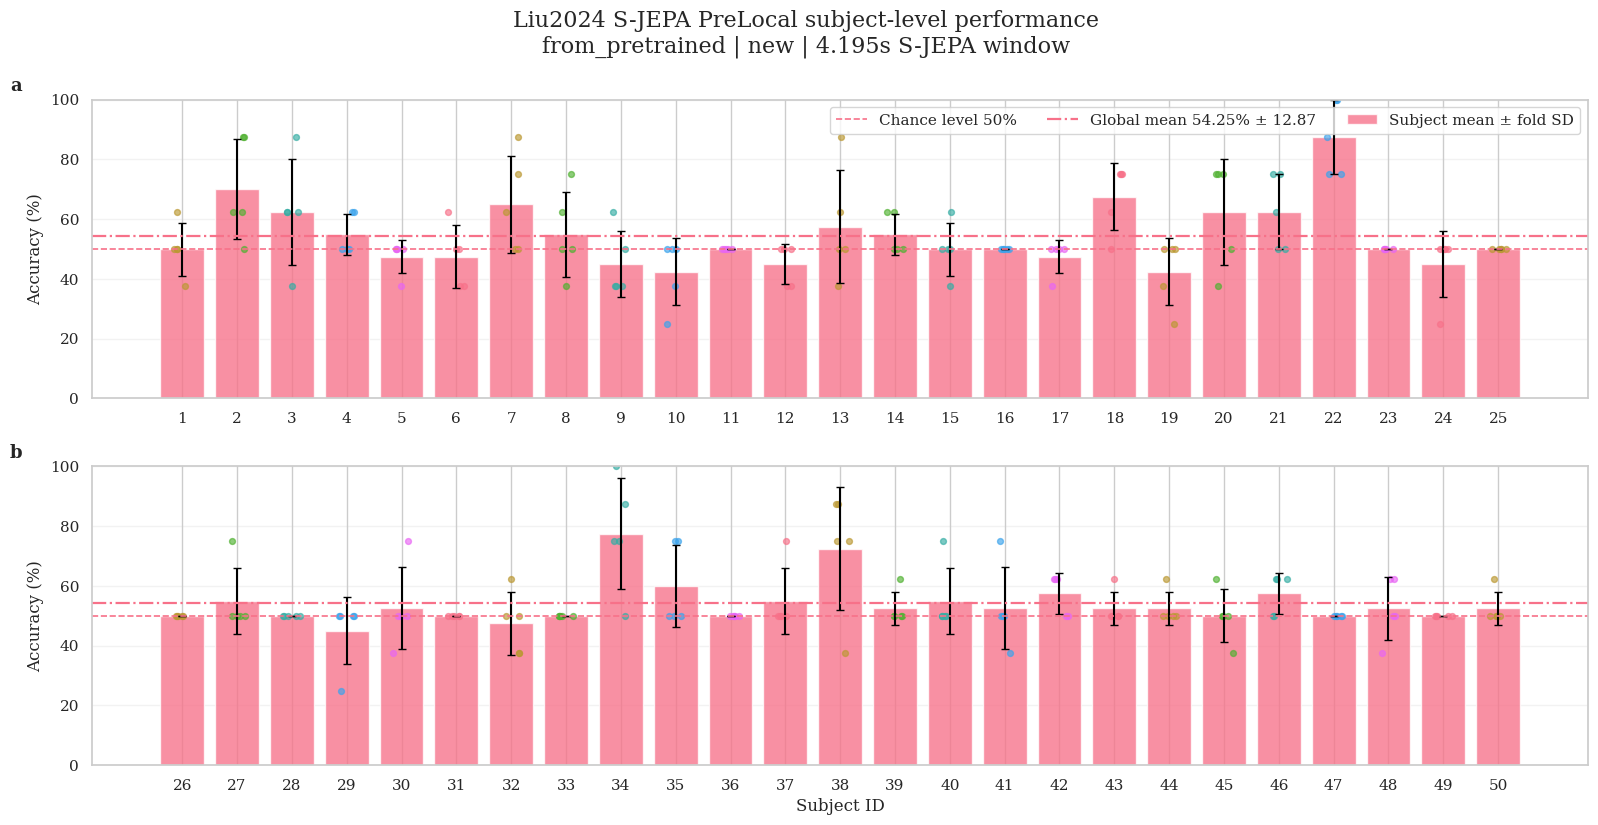

[2026-05-28 17:32:32] Subject performance plot saved to: /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/artifacts/liu2024-source-mat-sjepa-prelocal/20260528_1727_902358f8/sjepa_prelocal_subject_performance.png


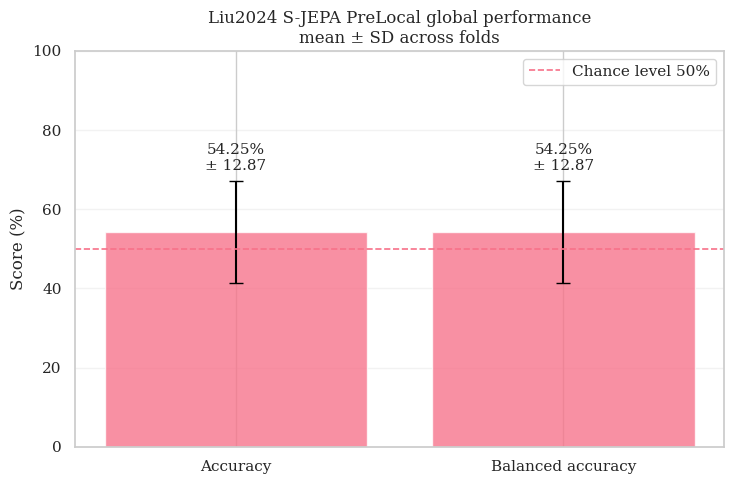

[2026-05-28 17:32:32] Global performance plot saved to: /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/artifacts/liu2024-source-mat-sjepa-prelocal/20260528_1727_902358f8/sjepa_prelocal_global_performance_summary.png


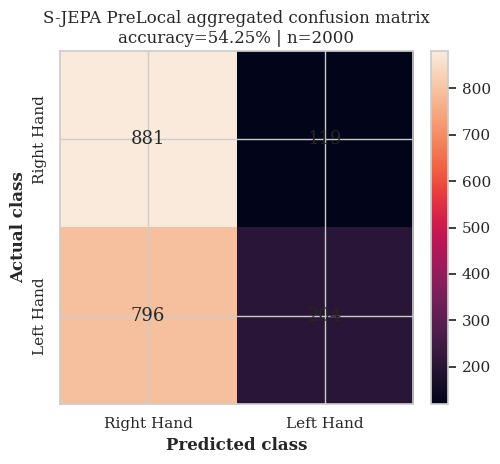

[2026-05-28 17:32:32] Aggregated confusion matrix plot saved to: /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/artifacts/liu2024-source-mat-sjepa-prelocal/20260528_1727_902358f8/sjepa_prelocal_aggregated_confusion_matrix.png
[2026-05-28 17:32:32] Confusion metrics saved to: /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/artifacts/liu2024-source-mat-sjepa-prelocal/20260528_1727_902358f8/sjepa_prelocal_confusion_metrics.csv


In [ ]:

def _safe_percent(value):
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return np.nan
    return float(value) * 100.0

def _jsonable(value):
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    return value

def build_performance_tables(fold_results):
    fold_rows = []
    for result in fold_results:
        prob = result.get("probability_diagnostics") or {}
        collapse = result.get("collapse_diagnostics") or {}
        fold_rows.append({
            "method_name": f"{CONFIG['model_name']}__{CONFIG['pretrained_mode']}__{CONFIG['strategy']}",
            "model_name": CONFIG["model_name"],
            "pretrained_mode": CONFIG["pretrained_mode"],
            "strategy": CONFIG["strategy"],
            "subject_id": str(result.get("subject_id")),
            "fold_id": int(result.get("fold_id")),
            "accuracy": result.get("accuracy"),
            "accuracy_percent": _safe_percent(result.get("accuracy")),
            "balanced_accuracy": result.get("balanced_accuracy"),
            "balanced_accuracy_percent": _safe_percent(result.get("balanced_accuracy")),
            "best_epoch": result.get("best_epoch"),
            "stopped_epoch": result.get("stopped_epoch"),
            "final_phase_epochs_ran": result.get("final_phase_epochs_ran"),
            "n_train": result.get("n_train"),
            "n_test": result.get("n_test"),
            "train_class_counts": json.dumps(result.get("train_class_counts")),
            "test_class_counts": json.dumps(result.get("test_class_counts")),
            "prediction_histogram": json.dumps(result.get("prediction_histogram")),
            "confusion_matrix": json.dumps(result.get("confusion_matrix")),
            "collapse_ratio": collapse.get("collapse_ratio"),
            "collapse_flag": collapse.get("collapse_flag"),
            "mean_confidence": prob.get("mean_confidence") if prob.get("available") else None,
            "mean_normalized_prediction_entropy": prob.get("mean_normalized_prediction_entropy") if prob.get("available") else None,
        })

    fold_df = pd.DataFrame(fold_rows)

    subject_df = (
        fold_df
        .groupby(["pretrained_mode", "strategy", "subject_id"], as_index=False)
        .agg(
            mean_accuracy=("accuracy", "mean"),
            std_accuracy=("accuracy", "std"),
            mean_accuracy_percent=("accuracy_percent", "mean"),
            std_accuracy_percent=("accuracy_percent", "std"),
            mean_balanced_accuracy=("balanced_accuracy", "mean"),
            std_balanced_accuracy=("balanced_accuracy", "std"),
            mean_balanced_accuracy_percent=("balanced_accuracy_percent", "mean"),
            std_balanced_accuracy_percent=("balanced_accuracy_percent", "std"),
            mean_confidence=("mean_confidence", "mean"),
            mean_normalized_prediction_entropy=("mean_normalized_prediction_entropy", "mean"),
            collapse_rate=("collapse_flag", "mean"),
            n_folds=("fold_id", "count"),
        )
    )
    subject_df["subject_id_int"] = subject_df["subject_id"].astype(str).map(_sort_subject_key)
    subject_df = subject_df.sort_values("subject_id_int").drop(columns=["subject_id_int"])

    method_df = (
        fold_df
        .groupby(["pretrained_mode", "strategy"], as_index=False)
        .agg(
            mean_accuracy=("accuracy", "mean"),
            std_accuracy=("accuracy", "std"),
            mean_accuracy_percent=("accuracy_percent", "mean"),
            std_accuracy_percent=("accuracy_percent", "std"),
            mean_balanced_accuracy=("balanced_accuracy", "mean"),
            std_balanced_accuracy=("balanced_accuracy", "std"),
            mean_balanced_accuracy_percent=("balanced_accuracy_percent", "mean"),
            std_balanced_accuracy_percent=("balanced_accuracy_percent", "std"),
            mean_confidence=("mean_confidence", "mean"),
            mean_normalized_prediction_entropy=("mean_normalized_prediction_entropy", "mean"),
            collapse_rate=("collapse_flag", "mean"),
            n_folds_total=("fold_id", "count"),
            n_subjects=("subject_id", lambda s: int(pd.Series(s).nunique())),
        )
    )

    return fold_df, subject_df, method_df

FOLD_PERFORMANCE_DF, SUBJECT_PERFORMANCE_DF, METHOD_PERFORMANCE_DF = build_performance_tables(FOLD_RESULTS)

fold_level_results_path = ARTIFACT_DIR / "fold_level_results.csv"
subject_level_summary_path = ARTIFACT_DIR / "subject_level_summary.csv"
global_method_comparison_path = ARTIFACT_DIR / "global_method_comparison.csv"

FOLD_PERFORMANCE_DF.to_csv(fold_level_results_path, index=False)
SUBJECT_PERFORMANCE_DF.to_csv(subject_level_summary_path, index=False)
METHOD_PERFORMANCE_DF.to_csv(global_method_comparison_path, index=False)

print("Performance tables saved:")
print(f"  Fold-level results:       {fold_level_results_path}")
print(f"  Subject-level summary:    {subject_level_summary_path}")
print(f"  Global method comparison: {global_method_comparison_path}")
display(METHOD_PERFORMANCE_DF)
display(SUBJECT_PERFORMANCE_DF.head(10))


def _split_subject_ids_for_plot(subject_ids):
    subject_ids = sorted([str(s) for s in subject_ids], key=_sort_subject_key)
    if len(subject_ids) <= 30:
        return [(subject_ids, "a")]
    midpoint = int(math.ceil(len(subject_ids) / 2))
    return [(subject_ids[:midpoint], "a"), (subject_ids[midpoint:], "b")]


def plot_subject_performance_with_folds(subject_df, fold_df):
    subject_ids = sorted(subject_df["subject_id"].astype(str).unique(), key=_sort_subject_key)
    panels = _split_subject_ids_for_plot(subject_ids)
    fig, axes = plt.subplots(len(panels), 1, figsize=(16, 4.2 * len(panels)), sharey=True)
    if len(panels) == 1:
        axes = [axes]

    global_mean = float(fold_df["accuracy_percent"].mean())
    global_std = float(fold_df["accuracy_percent"].std())
    rng = np.random.default_rng(123)

    for ax, (panel_subjects, panel_label) in zip(axes, panels):
        sub = (
            subject_df[subject_df["subject_id"].astype(str).isin(panel_subjects)]
            .copy()
            .sort_values("subject_id", key=lambda s: s.map(_sort_subject_key))
        )
        x = np.arange(len(sub))
        y = sub["mean_accuracy_percent"].to_numpy(dtype=float)
        yerr = sub["std_accuracy_percent"].fillna(0.0).to_numpy(dtype=float)

        ax.bar(x, y, yerr=yerr, capsize=3, alpha=0.78, label="Subject mean ± fold SD")

        for pos, sid in enumerate(sub["subject_id"].astype(str)):
            fold_values = (
                fold_df[fold_df["subject_id"].astype(str) == sid]["accuracy_percent"]
                .dropna()
                .to_numpy(dtype=float)
            )
            if len(fold_values):
                jitter = rng.uniform(-0.16, 0.16, size=len(fold_values))
                ax.scatter(np.full(len(fold_values), pos) + jitter, fold_values, s=18, alpha=0.65, label=None)

        ax.axhline(50.0, linestyle="--", linewidth=1.2, label="Chance level 50%" if panel_label == "a" else None)
        ax.axhline(global_mean, linestyle="-.", linewidth=1.6, label=f"Global mean {global_mean:.2f}% ± {global_std:.2f}" if panel_label == "a" else None)
        ax.set_ylim(0, 100)
        ax.set_ylabel("Accuracy (%)")
        ax.set_xticks(x)
        ax.set_xticklabels(sub["subject_id"].astype(str).tolist())
        ax.grid(axis="y", alpha=0.25)
        ax.text(-0.055, 1.03, panel_label, transform=ax.transAxes, fontweight="bold", fontsize=13)

    axes[0].legend(loc="upper right", ncol=3, frameon=True)
    axes[-1].set_xlabel("Subject ID")
    fig.suptitle(
        f"Liu2024 S-JEPA PreLocal subject-level performance\n"
        f"{CONFIG['pretrained_mode']} | {CONFIG['strategy']} | {TARGET_TRIAL_DURATION_S:.3f}s S-JEPA window",
        fontsize=16,
    )
    fig.tight_layout()

    out_path = ARTIFACT_DIR / "sjepa_prelocal_subject_performance.png"
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Subject performance plot saved to: {out_path}")
    return out_path


def plot_global_performance_summary(method_df):
    row = method_df.iloc[0]
    labels = ["Accuracy", "Balanced accuracy"]
    means = [
        float(row["mean_accuracy_percent"]),
        float(row["mean_balanced_accuracy_percent"]),
    ]
    errors = [
        float(row["std_accuracy_percent"]) if pd.notna(row["std_accuracy_percent"]) else 0.0,
        float(row["std_balanced_accuracy_percent"]) if pd.notna(row["std_balanced_accuracy_percent"]) else 0.0,
    ]

    fig, ax = plt.subplots(figsize=(7.5, 5))
    x = np.arange(len(labels))
    ax.bar(x, means, yerr=errors, capsize=5, alpha=0.78)
    ax.axhline(50.0, linestyle="--", linewidth=1.2, label="Chance level 50%")
    for pos, value, err in zip(x, means, errors):
        ax.text(pos, value + err + 2.0, f"{value:.2f}%\n± {err:.2f}", ha="center", va="bottom", fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel("Score (%)")
    ax.set_ylim(0, 100)
    ax.set_title("Liu2024 S-JEPA PreLocal global performance\nmean ± SD across folds")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(loc="upper right")
    fig.tight_layout()

    out_path = ARTIFACT_DIR / "sjepa_prelocal_global_performance_summary.png"
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Global performance plot saved to: {out_path}")
    return out_path


def _parse_confusion_matrix(value):
    if isinstance(value, str):
        return np.asarray(json.loads(value), dtype=int)
    return np.asarray(value, dtype=int)


def aggregate_confusion_matrix_from_folds(fold_df, author_order=True):
    mats = [_parse_confusion_matrix(v) for v in fold_df["confusion_matrix"]]
    cm = np.sum(mats, axis=0).astype(int)
    if author_order and cm.shape == (2, 2):
        # Stored order is [Left, Right] = [0, 1]. Paper-style visual order is [Right, Left].
        cm = cm[np.ix_([1, 0], [1, 0])]
    return cm


def plot_aggregated_confusion_matrix(fold_df):
    cm = aggregate_confusion_matrix_from_folds(fold_df, author_order=True)
    total = int(cm.sum())
    acc = float((cm[0, 0] + cm[1, 1]) / total * 100.0) if total else np.nan

    fig, ax = plt.subplots(figsize=(5.5, 4.8))
    im = ax.imshow(cm)
    ax.set_title(f"S-JEPA PreLocal aggregated confusion matrix\naccuracy={acc:.2f}% | n={total}")
    ax.set_xlabel("Predicted class", fontweight="bold")
    ax.set_ylabel("Actual class", fontweight="bold")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Right Hand", "Left Hand"])
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["Right Hand", "Left Hand"], rotation=90, va="center")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(int(cm[i, j])), ha="center", va="center", fontsize=13)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()

    out_path = ARTIFACT_DIR / "sjepa_prelocal_aggregated_confusion_matrix.png"
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Aggregated confusion matrix plot saved to: {out_path}")

    confusion_metrics_path = ARTIFACT_DIR / "sjepa_prelocal_confusion_metrics.csv"
    pd.DataFrame([{
        "method_name": f"{CONFIG['model_name']}__{CONFIG['pretrained_mode']}__{CONFIG['strategy']}",
        "confusion_matrix_right_left_order": cm.tolist(),
        "n_predictions": total,
        "accuracy_from_matrix_percent": acc,
    }]).to_csv(confusion_metrics_path, index=False)
    print(f"Confusion metrics saved to: {confusion_metrics_path}")
    return out_path, confusion_metrics_path


subject_performance_plot_path = plot_subject_performance_with_folds(SUBJECT_PERFORMANCE_DF, FOLD_PERFORMANCE_DF)
global_performance_plot_path = plot_global_performance_summary(METHOD_PERFORMANCE_DF)
confusion_performance_plot_path, confusion_metrics_path = plot_aggregated_confusion_matrix(FOLD_PERFORMANCE_DF)


## 6.3 Experiment Summary

In [ ]:
print("\n" + "=" * 70)
print("EXPERIMENT SUMMARY")
print("=" * 70)
print(f"Run ID:                 {RUN_ID}")
print(f"Experiment:             {CONFIG.get('experiment_name')}")
print(f"Subjects:               {len(SUBJECTS)}")
print(f"Model:                  {CONFIG['model_name']}")
print(f"Pretrained mode:        {CONFIG['pretrained_mode']}")
print(f"Strategy:               {CONFIG['strategy']}")
print(f"Preprocessing:          {CONFIG['demean_mode']} | ref={CONFIG['reference_mode']} | resample={CONFIG['resample']}->{CONFIG.get('resample_sfreq')} | filter={CONFIG['filter_enabled']} {CONFIG.get('filter_low')}–{CONFIG.get('filter_high')} {CONFIG.get('filter_method')}")
print(f"Window:                 start={CONFIG['mi_window_start_s']}s | {TARGET_TRIAL_DURATION_S:.3f}s / {WINDOW_SAMPLES} samples")
print(f"Artifacts:              {ARTIFACT_DIR}")
print(f"Mean Accuracy:          {GLOBAL_METRICS['mean_accuracy']:.4f} ± {GLOBAL_METRICS['std_accuracy']:.4f}")
print(f"Mean Balanced Accuracy: {GLOBAL_METRICS['mean_balanced_accuracy']:.4f} ± {GLOBAL_METRICS['std_balanced_accuracy']:.4f}")
print("=" * 70)



[2026-05-28 17:32:32] ======================================================================
[2026-05-28 17:32:32] EXPERIMENT SUMMARY
[2026-05-28 17:32:32] ======================================================================
[2026-05-28 17:32:32] Run ID:                 20260528_1727_902358f8
[2026-05-28 17:32:32] Experiment:             baseline_sjepa_prelocal
[2026-05-28 17:32:32] Subjects:               50
[2026-05-28 17:32:32] Model:                  SignalJEPA_PreLocal
[2026-05-28 17:32:32] Pretrained mode:        from_pretrained
[2026-05-28 17:32:32] Strategy:               new
[2026-05-28 17:32:32] Preprocessing:          baseline_window_mean | ref=average | resample=True->128 | filter=True 0.5–40.0 fir
[2026-05-28 17:32:32] Window:                 start=2s | 4.195s / 537 samples
[2026-05-28 17:32:32] Artifacts:              /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/artifacts/liu2024-source-mat-sjepa-prelocal/20260528_1727_902358f8
[2026

## 6.4 Spatial Convolution Weight Analysis

This section aggregates learned PreLocal `spatial_conv` weights across folds and saves CSV/JSON summaries plus topomap visualizations. The global and subject topomaps use a relative blue-red scale by default so channels below and above the within-run mean are visually separable.

In [ ]:
def collect_spatial_conv_records(fold_results):
    records = []
    for result in fold_results:
        spatial = result.get("spatial_conv")
        if not spatial or not spatial.get("available", False):
            continue
        ch_names = spatial["channel_names"]
        abs_scores = np.asarray(spatial["channel_abs_mean"], dtype=float)
        signed_scores = np.asarray(spatial["channel_signed_mean"], dtype=float)
        l2_scores = np.asarray(spatial["channel_l2"], dtype=float)
        collapse = result.get("collapse_diagnostics") or {}
        update_stats = result.get("spatial_update_stats") or {}
        for ch_idx, ch_name in enumerate(ch_names):
            records.append({
                "subject_id": result.get("subject_id"),
                "fold_id": result.get("fold_id"),
                "channel_index": ch_idx,
                "channel_name": ch_name,
                "abs_mean_weight": float(abs_scores[ch_idx]),
                "signed_mean_weight": float(signed_scores[ch_idx]),
                "l2_weight": float(l2_scores[ch_idx]),
                "accuracy": result.get("accuracy"),
                "balanced_accuracy": result.get("balanced_accuracy"),
                "prediction_histogram": result.get("prediction_histogram"),
                "collapse_ratio": collapse.get("collapse_ratio"),
                "collapse_flag": collapse.get("collapse_flag"),
                "spatial_delta_l2": update_stats.get("delta_l2"),
                "spatial_delta_max_abs": update_stats.get("delta_max_abs"),
                "spatial_relative_delta": update_stats.get("relative_delta"),
                "spatial_changed": update_stats.get("changed"),
            })
    return records

def collect_fold_diagnostic_records(fold_results):
    rows = []
    for result in fold_results:
        collapse = result.get("collapse_diagnostics") or {}
        update_stats = result.get("spatial_update_stats") or {}
        prob = result.get("probability_diagnostics") or {}
        rows.append({
            "subject_id": result.get("subject_id"),
            "fold_id": result.get("fold_id"),
            "accuracy": result.get("accuracy"),
            "balanced_accuracy": result.get("balanced_accuracy"),
            "prediction_histogram": result.get("prediction_histogram"),
            "collapse_ratio": collapse.get("collapse_ratio"),
            "collapse_flag": collapse.get("collapse_flag"),
            "majority_predicted_class": collapse.get("majority_predicted_class"),
            "spatial_delta_l2": update_stats.get("delta_l2"),
            "spatial_delta_max_abs": update_stats.get("delta_max_abs"),
            "spatial_relative_delta": update_stats.get("relative_delta"),
            "spatial_changed": update_stats.get("changed"),
            "mean_confidence": prob.get("mean_confidence") if prob.get("available") else None,
            "mean_normalized_prediction_entropy": prob.get("mean_normalized_prediction_entropy") if prob.get("available") else None,
            "n_trainable_params_final": result.get("n_trainable_params_final"),
        })
    return rows

SPATIAL_CONV_RECORDS = collect_spatial_conv_records(FOLD_RESULTS)
FOLD_DIAGNOSTIC_RECORDS = collect_fold_diagnostic_records(FOLD_RESULTS)

if CONFIG["model_name"] != "SignalJEPA_PreLocal":
    print("Spatial convolution analysis skipped: selected model is not SignalJEPA_PreLocal.")
elif not CONFIG.get("extract_spatial_conv_weights", False):
    print("Spatial convolution analysis skipped: CONFIG['extract_spatial_conv_weights'] is False.")
elif len(SPATIAL_CONV_RECORDS) == 0:
    print("Spatial convolution analysis skipped: no available spatial_conv records were extracted.")
else:
    spatial_dir = ARTIFACT_DIR / "spatial_conv_analysis"
    spatial_dir.mkdir(parents=True, exist_ok=True)

    spatial_records_path = spatial_dir / "spatial_channel_importance_long.csv"
    spatial_df = pd.DataFrame(SPATIAL_CONV_RECORDS)
    spatial_df.to_csv(spatial_records_path, index=False)

    fold_diagnostics_path = spatial_dir / "fold_diagnostics.csv"
    fold_diag_df = pd.DataFrame(FOLD_DIAGNOSTIC_RECORDS)
    fold_diag_df.to_csv(fold_diagnostics_path, index=False)

    fold_spatial_json = []
    for result in FOLD_RESULTS:
        spatial = result.get("spatial_conv")
        if spatial and spatial.get("available", False):
            fold_spatial_json.append({
                "subject_id": result.get("subject_id"),
                "fold_id": result.get("fold_id"),
                "accuracy": result.get("accuracy"),
                "balanced_accuracy": result.get("balanced_accuracy"),
                "prediction_histogram": result.get("prediction_histogram"),
                "collapse_diagnostics": result.get("collapse_diagnostics"),
                "probability_diagnostics": result.get("probability_diagnostics"),
                "spatial_update_stats": result.get("spatial_update_stats"),
                "n_trainable_params_final": result.get("n_trainable_params_final"),
                "spatial_conv": spatial,
            })
    fold_json_path = spatial_dir / "spatial_conv_weights_by_fold.json"
    with open(fold_json_path, "w") as f:
        json.dump(fold_spatial_json, f, indent=2)

    global_summary_df = (
        spatial_df
        .groupby(["channel_index", "channel_name"], as_index=False)
        .agg(
            mean_abs_weight=("abs_mean_weight", "mean"),
            std_abs_weight=("abs_mean_weight", "std"),
            mean_signed_weight=("signed_mean_weight", "mean"),
            mean_l2_weight=("l2_weight", "mean"),
            n_fold_values=("abs_mean_weight", "count"),
            mean_collapse_ratio=("collapse_ratio", "mean"),
            collapse_rate=("collapse_flag", "mean"),
            mean_spatial_relative_delta=("spatial_relative_delta", "mean"),
        )
        .sort_values("mean_abs_weight", ascending=False)
    )
    global_summary_path = spatial_dir / "spatial_channel_importance_global.csv"
    global_summary_df.to_csv(global_summary_path, index=False)

    subject_summary_df = (
        spatial_df
        .groupby(["subject_id", "channel_index", "channel_name"], as_index=False)
        .agg(
            mean_abs_weight=("abs_mean_weight", "mean"),
            std_abs_weight=("abs_mean_weight", "std"),
            mean_signed_weight=("signed_mean_weight", "mean"),
            mean_l2_weight=("l2_weight", "mean"),
            n_fold_values=("abs_mean_weight", "count"),
            mean_collapse_ratio=("collapse_ratio", "mean"),
            collapse_rate=("collapse_flag", "mean"),
            mean_spatial_relative_delta=("spatial_relative_delta", "mean"),
        )
        .sort_values(["subject_id", "mean_abs_weight"], ascending=[True, False])
    )
    subject_summary_path = spatial_dir / "spatial_channel_importance_by_subject.csv"
    subject_summary_df.to_csv(subject_summary_path, index=False)

    if len(fold_diag_df) > 0:
        diagnostic_summary = {
            "n_folds": int(len(fold_diag_df)),
            "collapse_rate": float(fold_diag_df["collapse_flag"].fillna(False).mean()),
            "mean_collapse_ratio": float(fold_diag_df["collapse_ratio"].dropna().mean()) if fold_diag_df["collapse_ratio"].notna().any() else None,
            "mean_spatial_delta_l2": float(fold_diag_df["spatial_delta_l2"].dropna().mean()) if fold_diag_df["spatial_delta_l2"].notna().any() else None,
            "mean_spatial_relative_delta": float(fold_diag_df["spatial_relative_delta"].dropna().mean()) if fold_diag_df["spatial_relative_delta"].notna().any() else None,
            "spatial_changed_rate": float(fold_diag_df["spatial_changed"].fillna(False).mean()) if "spatial_changed" in fold_diag_df else None,
            "mean_confidence": float(fold_diag_df["mean_confidence"].dropna().mean()) if fold_diag_df["mean_confidence"].notna().any() else None,
            "mean_normalized_prediction_entropy": float(fold_diag_df["mean_normalized_prediction_entropy"].dropna().mean()) if fold_diag_df["mean_normalized_prediction_entropy"].notna().any() else None,
        }
    else:
        diagnostic_summary = {}
    diagnostic_summary_path = spatial_dir / "diagnostic_summary.json"
    with open(diagnostic_summary_path, "w") as f:
        json.dump(diagnostic_summary, f, indent=2)

    print("\nSpatial convolution analysis saved:")
    print(f"  Long channel CSV:        {spatial_records_path}")
    print(f"  Fold diagnostics CSV:    {fold_diagnostics_path}")
    print(f"  Fold weight JSON:        {fold_json_path}")
    print(f"  Global importance CSV:   {global_summary_path}")
    print(f"  Subject importance CSV:  {subject_summary_path}")
    print(f"  Diagnostic summary JSON: {diagnostic_summary_path}")

    print("\nDiagnostic summary:")
    print(json.dumps(diagnostic_summary, indent=2))
    print("\nTop global channels by mean absolute spatial weight:")
    display(global_summary_df.head(15))

    if bool(CONFIG.get("save_spatial_weight_plots", True)):
        ch_names = list(fold_spatial_json[0]["spatial_conv"]["channel_names"])
        global_values = np.zeros(len(ch_names), dtype=float)
        for _, row in global_summary_df.iterrows():
            global_values[int(row["channel_index"])] = float(row["mean_abs_weight"])

        global_topomap_path = spatial_dir / "global_mean_abs_spatial_weight_topomap.png"
        plot_spatial_topomap(
            global_values,
            ch_names=ch_names,
            title="global mean abs spatial_conv weight",
            out_path=global_topomap_path,
        )
        print(f"  Global topomap:          {global_topomap_path}")

        matrices = []
        for item in fold_spatial_json:
            matrices.append(np.asarray(item["spatial_conv"]["weight_matrix_norm"], dtype=float))
        if matrices:
            min_filters = min(m.shape[0] for m in matrices)
            matrices = [m[:min_filters] for m in matrices]
            global_filter_matrix = np.mean(np.stack(matrices, axis=0), axis=0)
            filter_grid_path = spatial_dir / "global_mean_spatial_filters_topomap_grid.png"
            plot_spatial_filter_grid(
                global_filter_matrix,
                ch_names=ch_names,
                title="mean normalized spatial filters",
                out_path=filter_grid_path,
                max_filters=int(CONFIG.get("max_spatial_filters_to_plot", 8)),
            )
            print(f"  Global filter grid:      {filter_grid_path}")

        for subject_id in sorted(spatial_df["subject_id"].dropna().unique(), key=_sort_subject_key):
            sub_df = subject_summary_df[subject_summary_df["subject_id"] == subject_id]
            subject_values = np.zeros(len(ch_names), dtype=float)
            for _, row in sub_df.iterrows():
                subject_values[int(row["channel_index"])] = float(row["mean_abs_weight"])
            subject_topomap_path = spatial_dir / f"subject_{subject_id}_mean_abs_spatial_weight_topomap.png"
            plot_spatial_topomap(
                subject_values,
                ch_names=ch_names,
                title=f"subject {subject_id} mean abs spatial_conv weight",
                out_path=subject_topomap_path,
            )
        print(f"  Subject topomaps saved in: {spatial_dir}")



[2026-05-28 17:32:32] Spatial convolution analysis saved:
[2026-05-28 17:32:32]   Long channel CSV:        /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/artifacts/liu2024-source-mat-sjepa-prelocal/20260528_1727_902358f8/spatial_conv_analysis/spatial_channel_importance_long.csv
[2026-05-28 17:32:32]   Fold diagnostics CSV:    /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/artifacts/liu2024-source-mat-sjepa-prelocal/20260528_1727_902358f8/spatial_conv_analysis/fold_diagnostics.csv
[2026-05-28 17:32:32]   Fold weight JSON:        /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/artifacts/liu2024-source-mat-sjepa-prelocal/20260528_1727_902358f8/spatial_conv_analysis/spatial_conv_weights_by_fold.json
[2026-05-28 17:32:32]   Global importance CSV:   /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/artifacts/liu2024-source-mat-sjepa-prelocal/20260528_1727_90235

,channel_index,channel_name,mean_abs_weight,std_abs_weight,mean_signed_weight,mean_l2_weight,n_fold_values,mean_collapse_ratio,collapse_rate,mean_spatial_relative_delta
21,21,Pz,0.152926,0.003400,0.006028,0.153246,250,0.8625,0.536,0.048203
28,28,O2,0.144498,0.003602,-0.023314,0.147350,250,0.8625,0.536,0.048203
15,15,T3,0.126910,0.004007,0.126910,0.132521,250,0.8625,0.536,0.048203
27,27,O1,0.122316,0.004375,0.055939,0.132953,250,0.8625,0.536,0.048203
16,16,T4,0.121778,0.003497,0.014255,0.134462,250,0.8625,0.536,0.048203
17,17,CP3,0.121207,0.003545,0.031978,0.139076,250,0.8625,0.536,0.048203
13,13,C3,0.115020,0.003920,0.071618,0.117349,250,0.8625,0.536,0.048203
18,18,CP4,0.110973,0.004202,0.034547,0.127613,250,0.8625,0.536,0.048203
0,0,Fp1,0.109860,0.003893,-0.096135,0.122842,250,0.8625,0.536,0.048203
22,22,P3,0.107347,0.004482,0.107347,0.116848,250,0.8625,0.536,0.048203


## 6.5 Save Artifacts

In [ ]:
cv_results_path = ARTIFACT_DIR / "cv_results.json"
with open(cv_results_path, "w") as f:
    json.dump(FOLD_RESULTS, f, indent=2)

subject_metrics_path = ARTIFACT_DIR / "subject_metrics.json"
with open(subject_metrics_path, "w") as f:
    json.dump(SUBJECT_METRICS, f, indent=2)

global_metrics_path = ARTIFACT_DIR / "global_metrics.json"
with open(global_metrics_path, "w") as f:
    json.dump(GLOBAL_METRICS, f, indent=2)

run_metadata = {
    "run_id": RUN_ID,
    "artifact_dir": str(ARTIFACT_DIR),
    "experiment_name": CONFIG.get("experiment_name"),
    "config_note": CONFIG.get("config_note"),
    "config_override_path": CONFIG.get("config_override_path"),
    "config_sweep_index": CONFIG.get("config_sweep_index"),
    "excluded_subjects": list(CONFIG["exclude_subjects"]),
    "subjects": [str(s) for s in SUBJECTS],
    "source_sfreq": LIU_SOURCE_SFREQ,
    "effective_sfreq": EFFECTIVE_SFREQ,
    "preprocessing_config": PREPROCESSING_CONFIG,
    "preprocessing_order": preprocessing_steps_first_subject if "preprocessing_steps_first_subject" in globals() else None,
    "mi_window_start_s": CONFIG["mi_window_start_s"],
    "target_window_duration_s": TARGET_TRIAL_DURATION_S,
    "window_samples": WINDOW_SAMPLES,
    "mi_window_start_sample": MI_WINDOW_START_SAMPLE,
    "mi_window_stop_sample": MI_WINDOW_STOP_SAMPLE,
    "expected_trials_per_subject": LIU_EXPECTED_TRIALS_PER_SUBJECT,
    "expected_source_channels": LIU_EXPECTED_SOURCE_CHANNELS,
    "expected_source_samples_per_trial": LIU_EXPECTED_SOURCE_SAMPLES_PER_TRIAL,
    "source_unit": CONFIG["source_unit"],
    "final_model_unit": CONFIG["final_model_unit"],
    "subject_inventory_path": str(subject_inventory_path),
    "window_summary_path": str(window_summary_path),
    "channel_names": list(CH_NAMES),
    "n_channels": len(CH_NAMES),
    "model_name": CONFIG["model_name"],
    "pretrained_mode": CONFIG["pretrained_mode"],
    "pretrained_repo_id": CONFIG["pretrained_repo_id"],
    "strategy": CONFIG["strategy"],
    "warmup_epochs": int(CONFIG["warmup_epochs"]),
    "optimizer": CONFIG["optimizer_name"],
    "learning_rate": CONFIG["learning_rate"],
    "augmentation_noise_fraction": CONFIG["augmentation_noise_fraction"],
    "pretrained_checkpoint_info": PRETRAINED_CHECKPOINT_INFO,
    "seed": BASE_SEED,
    "cv_seed": CONFIG.get("cv_random_state"),
    "val_split_seed": CONFIG.get("val_split_random_state"),
    "cv_folds": CONFIG["cv_folds"],
    "val_split": CONFIG["val_split"],
    "global_metrics": GLOBAL_METRICS,
    "performance_artifacts": {
        "fold_level_results": str(fold_level_results_path) if "fold_level_results_path" in globals() else None,
        "subject_level_summary": str(subject_level_summary_path) if "subject_level_summary_path" in globals() else None,
        "global_method_comparison": str(global_method_comparison_path) if "global_method_comparison_path" in globals() else None,
        "subject_performance_plot": str(subject_performance_plot_path) if "subject_performance_plot_path" in globals() else None,
        "global_performance_plot": str(global_performance_plot_path) if "global_performance_plot_path" in globals() else None,
        "aggregated_confusion_plot": str(confusion_performance_plot_path) if "confusion_performance_plot_path" in globals() else None,
        "confusion_metrics": str(confusion_metrics_path) if "confusion_metrics_path" in globals() else None,
    },
    "extract_spatial_conv_weights": bool(CONFIG.get("extract_spatial_conv_weights", False)),
    "save_spatial_weight_plots": bool(CONFIG.get("save_spatial_weight_plots", False)),
    "topomap_value_mode": CONFIG.get("topomap_value_mode"),
    "topomap_cmap": CONFIG.get("topomap_cmap"),
    "collapse_threshold": float(CONFIG.get("collapse_threshold", 0.90)),
    "log_spatial_update_stats": bool(CONFIG.get("log_spatial_update_stats", True)),
    "log_probability_diagnostics": bool(CONFIG.get("log_probability_diagnostics", True)),
}

run_metadata_path = ARTIFACT_DIR / "run_metadata.json"
with open(run_metadata_path, "w") as f:
    json.dump(run_metadata, f, indent=2)

print(f"CV results saved to:      {cv_results_path}")
print(f"Subject metrics saved to: {subject_metrics_path}")
print(f"Global metrics saved to:  {global_metrics_path}")
if "subject_performance_plot_path" in globals():
    print(f"Subject performance plot: {subject_performance_plot_path}")
if "global_performance_plot_path" in globals():
    print(f"Global performance plot:  {global_performance_plot_path}")
if "confusion_performance_plot_path" in globals():
    print(f"Confusion matrix plot:    {confusion_performance_plot_path}")
print(f"Run metadata saved to:    {run_metadata_path}")
print(f"\nAll artifacts in: {ARTIFACT_DIR}")

try:
    _LOG_FILE_HANDLE.close()
except Exception:
    pass


[2026-05-28 17:32:32] CV results saved to:      /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/artifacts/liu2024-source-mat-sjepa-prelocal/20260528_1727_902358f8/cv_results.json
[2026-05-28 17:32:32] Subject metrics saved to: /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/artifacts/liu2024-source-mat-sjepa-prelocal/20260528_1727_902358f8/subject_metrics.json
[2026-05-28 17:32:32] Global metrics saved to:  /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/artifacts/liu2024-source-mat-sjepa-prelocal/20260528_1727_902358f8/global_metrics.json
[2026-05-28 17:32:32] Subject performance plot: /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/artifacts/liu2024-source-mat-sjepa-prelocal/20260528_1727_902358f8/sjepa_prelocal_subject_performance.png
[2026-05-28 17:32:32] Global performance plot:  /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/